In [1]:
from pathlib import Path

import pandas as pd
from huggingface_hub import hf_hub_download


WEBNLG_DIR = (
    Path.home()
    / "MyWork"
    / "datasets"
    / "webnlg"
)

WEBNLG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPOSITORY = "GEM/web_nlg"

REVISION = (
    "d0d25090d354bebc8abfba543d22b8dcb9ca7f30"
)

WEBNLG_FILES = {
    "train": "en/web_nlg-train.parquet",
    "validation": "en/web_nlg-validation.parquet",
    "test": "en/web_nlg-test.parquet"
}

webnlg_dataframes = {}

for split_name, repository_filename in WEBNLG_FILES.items():

    print(f"Downloading {split_name}...")

    downloaded_path = hf_hub_download(
        repo_id=REPOSITORY,
        repo_type="dataset",
        filename=repository_filename,
        revision=REVISION,
        local_dir=WEBNLG_DIR
    )

    dataframe = pd.read_parquet(
        downloaded_path
    )

    webnlg_dataframes[split_name] = dataframe

    print(
        split_name,
        "examples:",
        len(dataframe)
    )


webnlg_train_df = webnlg_dataframes["train"]
webnlg_validation_df = webnlg_dataframes["validation"]
webnlg_test_df = webnlg_dataframes["test"]


print("\n========== WEBNLG LOADED ==========")

print(
    "Train examples:",
    len(webnlg_train_df)
)

print(
    "Validation examples:",
    len(webnlg_validation_df)
)

print(
    "Test examples:",
    len(webnlg_test_df)
)

print("\nColumns:")
print(webnlg_train_df.columns.tolist())

print("\nFirst training example:")
print(webnlg_train_df.iloc[0].to_dict())

print("\nSaved in:")
print(WEBNLG_DIR)


train examples: 35426
validation examples: 1667
test examples: 1779

========== WEBNLG LOADED ==========
Train examples: 35426
Validation examples: 1667
Test examples: 1779

Columns:
['gem_id', 'gem_parent_id', 'input', 'target', 'references', 'category', 'webnlg_id']

First training example:
{'gem_id': 'web_nlg_en-train-0', 'gem_parent_id': 'web_nlg_en-train-0', 'input': array(['Aarhus_Airport | cityServed | "Aarhus, Denmark"'], dtype=object), 'target': 'The Aarhus is the airport of Aarhus, Denmark.', 'references': array([], dtype=object), 'category': 'Airport', 'webnlg_id': 'train/Airport/1/Id1'}

Saved in:
/home/shahd.baloum/MyWork/datasets/webnlg


In [2]:
print("WebNLG directory:")
print(WEBNLG_DIR)

print("\nDownloaded files:")

for path in sorted(WEBNLG_DIR.rglob("*")):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)

        print(
            path.relative_to(WEBNLG_DIR),
            f"- {size_mb:.2f} MB"
        )

WebNLG directory:
/home/shahd.baloum/MyWork/datasets/webnlg

Downloaded files:
.cache/huggingface/.gitignore - 0.00 MB
.cache/huggingface/CACHEDIR.TAG - 0.00 MB
.cache/huggingface/download/en/web_nlg-test.parquet.lock - 0.00 MB
.cache/huggingface/download/en/web_nlg-test.parquet.metadata - 0.00 MB
.cache/huggingface/download/en/web_nlg-train.parquet.lock - 0.00 MB
.cache/huggingface/download/en/web_nlg-train.parquet.metadata - 0.00 MB
.cache/huggingface/download/en/web_nlg-validation.parquet.lock - 0.00 MB
.cache/huggingface/download/en/web_nlg-validation.parquet.metadata - 0.00 MB
en/web_nlg-test.parquet - 0.45 MB
en/web_nlg-train.parquet - 2.27 MB
en/web_nlg-validation.parquet - 0.41 MB
webnlg_dataset_summary.csv - 0.00 MB


In [2]:
#import os

#os.environ["PATH"] = (
 #   "/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin:"
  #  "/usr/local/cuda/bin:"
   # "/usr/local/bin:"
    #"/usr/bin:"
    #"/bin"
#)

#print("PATH fixed:", os.environ["PATH"])

PATH fixed: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin:/usr/local/cuda/bin:/usr/local/bin:/usr/bin:/bin


In [3]:
for split_name, dataframe in webnlg_dataframes.items():

    print("\n" + "=" * 70)
    print(f"SPLIT: {split_name.upper()}")
    print("=" * 70)

    print("Shape:")
    print(dataframe.shape)

    print("\nColumns:")
    print(dataframe.columns.tolist())

    print("\nData types:")
    print(dataframe.dtypes)


SPLIT: TRAIN
Shape:
(35426, 7)

Columns:
['gem_id', 'gem_parent_id', 'input', 'target', 'references', 'category', 'webnlg_id']

Data types:
gem_id              str
gem_parent_id       str
input            object
target              str
references       object
category            str
webnlg_id           str
dtype: object

SPLIT: VALIDATION
Shape:
(1667, 7)

Columns:
['gem_id', 'gem_parent_id', 'input', 'target', 'references', 'category', 'webnlg_id']

Data types:
gem_id              str
gem_parent_id       str
input            object
target              str
references       object
category            str
webnlg_id           str
dtype: object

SPLIT: TEST
Shape:
(1779, 7)

Columns:
['gem_id', 'gem_parent_id', 'input', 'target', 'references', 'category', 'webnlg_id']

Data types:
gem_id              str
gem_parent_id       str
input            object
target              str
references       object
category            str
webnlg_id           str
dtype: object


In [4]:
print(webnlg_train_df.iloc[0].to_dict())

{'gem_id': 'web_nlg_en-train-0', 'gem_parent_id': 'web_nlg_en-train-0', 'input': array(['Aarhus_Airport | cityServed | "Aarhus, Denmark"'], dtype=object), 'target': 'The Aarhus is the airport of Aarhus, Denmark.', 'references': array([], dtype=object), 'category': 'Airport', 'webnlg_id': 'train/Airport/1/Id1'}


In [5]:
pd.set_option(
    "display.max_colwidth",
    None
)

pd.set_option(
    "display.max_columns",
    None
)

display(
    webnlg_train_df.head(3)
)

,gem_id,gem_parent_id,input,target,references,category,webnlg_id
0,web_nlg_en-train-0,web_nlg_en-train-0,"[Aarhus_Airport | cityServed | ""Aarhus, Denmark""]","The Aarhus is the airport of Aarhus, Denmark.",[],Airport,train/Airport/1/Id1
1,web_nlg_en-train-1,web_nlg_en-train-1,"[Aarhus_Airport | cityServed | ""Aarhus, Denmark""]","Aarhus Airport serves the city of Aarhus, Denmark.",[],Airport,train/Airport/1/Id1
2,web_nlg_en-train-2,web_nlg_en-train-2,[Aarhus_Airport | cityServed | Aarhus],Aarhus airport serves the city of Aarhus.,[],Airport,train/Airport/1/Id2


In [6]:
first_example = webnlg_train_df.iloc[0]

print("FIRST WEBNLG EXAMPLE")
print("=" * 70)

for column_name in webnlg_train_df.columns:

    value = first_example[column_name]

    print(f"\nCOLUMN: {column_name}")
    print(f"PYTHON TYPE: {type(value)}")
    print("VALUE:")
    print(value)

FIRST WEBNLG EXAMPLE

COLUMN: gem_id
PYTHON TYPE: <class 'str'>
VALUE:
web_nlg_en-train-0

COLUMN: gem_parent_id
PYTHON TYPE: <class 'str'>
VALUE:
web_nlg_en-train-0

COLUMN: input
PYTHON TYPE: <class 'numpy.ndarray'>
VALUE:
['Aarhus_Airport | cityServed | "Aarhus, Denmark"']

COLUMN: target
PYTHON TYPE: <class 'str'>
VALUE:
The Aarhus is the airport of Aarhus, Denmark.

COLUMN: references
PYTHON TYPE: <class 'numpy.ndarray'>
VALUE:
[]

COLUMN: category
PYTHON TYPE: <class 'str'>
VALUE:
Airport

COLUMN: webnlg_id
PYTHON TYPE: <class 'str'>
VALUE:
train/Airport/1/Id1


In [7]:
for column_name in webnlg_train_df.columns:

    non_null_values = (
        webnlg_train_df[column_name]
        .dropna()
    )

    if len(non_null_values) == 0:
        example_type = None
        example_value = None
    else:
        example_value = non_null_values.iloc[0]
        example_type = type(example_value)

    print("\n" + "-" * 70)
    print("Column:", column_name)
    print("Pandas dtype:", webnlg_train_df[column_name].dtype)
    print("Python type:", example_type)
    print("Example value:")
    print(example_value)


----------------------------------------------------------------------
Column: gem_id
Pandas dtype: str
Python type: <class 'str'>
Example value:
web_nlg_en-train-0

----------------------------------------------------------------------
Column: gem_parent_id
Pandas dtype: str
Python type: <class 'str'>
Example value:
web_nlg_en-train-0

----------------------------------------------------------------------
Column: input
Pandas dtype: object
Python type: <class 'numpy.ndarray'>
Example value:
['Aarhus_Airport | cityServed | "Aarhus, Denmark"']

----------------------------------------------------------------------
Column: target
Pandas dtype: str
Python type: <class 'str'>
Example value:
The Aarhus is the airport of Aarhus, Denmark.

----------------------------------------------------------------------
Column: references
Pandas dtype: object
Python type: <class 'numpy.ndarray'>
Example value:
[]

----------------------------------------------------------------------
Column: category
P

In [8]:
def missing_value_report(dataframe):

    report = pd.DataFrame({
        "column": dataframe.columns,
        "missing_count": [
            dataframe[column].isna().sum()
            for column in dataframe.columns
        ],
        "missing_percent": [
            100 * dataframe[column].isna().mean()
            for column in dataframe.columns
        ]
    })

    return report


for split_name, dataframe in webnlg_dataframes.items():

    print("\n" + "=" * 70)
    print(f"MISSING VALUES — {split_name.upper()}")
    print("=" * 70)

    display(
        missing_value_report(dataframe)
    )


MISSING VALUES — TRAIN


,column,missing_count,missing_percent
0,gem_id,0,0.0
1,gem_parent_id,0,0.0
2,input,0,0.0
3,target,0,0.0
4,references,0,0.0
5,category,0,0.0
6,webnlg_id,0,0.0



MISSING VALUES — VALIDATION


,column,missing_count,missing_percent
0,gem_id,0,0.0
1,gem_parent_id,0,0.0
2,input,0,0.0
3,target,0,0.0
4,references,0,0.0
5,category,0,0.0
6,webnlg_id,0,0.0



MISSING VALUES — TEST


,column,missing_count,missing_percent
0,gem_id,0,0.0
1,gem_parent_id,0,0.0
2,input,0,0.0
3,target,0,0.0
4,references,0,0.0
5,category,0,0.0
6,webnlg_id,0,0.0


In [9]:
for split_name, dataframe in webnlg_dataframes.items():

    string_dataframe = dataframe.astype(str)

    duplicate_count = (
        string_dataframe
        .duplicated()
        .sum()
    )

    print(
        split_name,
        "duplicate rows:",
        duplicate_count
    )

train duplicate rows: 0
validation duplicate rows: 0
test duplicate rows: 0


In [10]:
for split_name, dataframe in webnlg_dataframes.items():

    string_dataframe = dataframe.astype(str)

    duplicate_count = (
        string_dataframe
        .duplicated()
        .sum()
    )

    print(
        split_name,
        "duplicate rows:",
        duplicate_count
    )

train duplicate rows: 0
validation duplicate rows: 0
test duplicate rows: 0


In [11]:
dataset_summary_rows = []

for split_name, dataframe in webnlg_dataframes.items():

    dataset_summary_rows.append({
        "split": split_name,
        "examples": len(dataframe),
        "columns": len(dataframe.columns),
        "missing_cells": int(
            dataframe.isna().sum().sum()
        )
    })

webnlg_summary_df = pd.DataFrame(
    dataset_summary_rows
)

display(webnlg_summary_df)

,split,examples,columns,missing_cells
0,train,35426,7,0
1,validation,1667,7,0
2,test,1779,7,0


In [12]:
SUMMARY_PATH = (
    WEBNLG_DIR
    / "webnlg_dataset_summary.csv"
)

webnlg_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

print("Summary saved to:")
print(SUMMARY_PATH)

Summary saved to:
/home/shahd.baloum/MyWork/datasets/webnlg/webnlg_dataset_summary.csv


In [13]:
import numpy as np


def convert_webnlg_input_to_text(input_value):
    """
    Convert a WebNLG input array into one text string.
    """

    if isinstance(input_value, np.ndarray):
        triples = input_value.tolist()

    elif isinstance(input_value, list):
        triples = input_value

    else:
        raise TypeError(
            f"Expected numpy.ndarray or list, got {type(input_value)}"
        )

    cleaned_triples = [
        str(triple).strip()
        for triple in triples
        if str(triple).strip()
    ]

    return " ; ".join(cleaned_triples)

In [14]:
first_input = webnlg_train_df.iloc[0]["input"]

converted_input = convert_webnlg_input_to_text(
    first_input
)

print("Original input:")
print(first_input)

print("\nConverted input:")
print(converted_input)

Original input:
['Aarhus_Airport | cityServed | "Aarhus, Denmark"']

Converted input:
Aarhus_Airport | cityServed | "Aarhus, Denmark"


In [15]:
multi_triple_rows = webnlg_train_df[
    webnlg_train_df["input"].apply(
        lambda value: len(value) > 1
    )
]

print(
    "Examples with more than one triple:",
    len(multi_triple_rows)
)

Examples with more than one triple: 27740


In [16]:
multi_triple_example = (
    multi_triple_rows
    .iloc[0]
)

print("Original input:")
print(
    multi_triple_example["input"]
)

print("\nConverted input:")
print(
    convert_webnlg_input_to_text(
        multi_triple_example["input"]
    )
)

print("\nTarget:")
print(
    multi_triple_example["target"]
)

Original input:
['Aarhus | leader | Jacob_Bundsgaard'
 'Aarhus_Airport | cityServed | Aarhus']

Converted input:
Aarhus | leader | Jacob_Bundsgaard ; Aarhus_Airport | cityServed | Aarhus

Target:
Aarhus airport serves the city of Aarhus whose leader is Jacob Bundsgaard.


In [17]:
SYSTEM_PROMPT = (
    "You are a data-to-text generation assistant. "
    "Convert structured RDF triples into fluent and accurate English. "
    "Include every supported fact and do not invent information."
)

In [18]:
def build_webnlg_user_prompt(source_text):
    return (
        "Convert the following RDF triples into fluent English.\n\n"
        f"RDF triples:\n{source_text}\n\n"
        "Generated text:"
    )

In [19]:
sample_prompt = build_webnlg_user_prompt(
    converted_input
)

print(sample_prompt)

Convert the following RDF triples into fluent English.

RDF triples:
Aarhus_Airport | cityServed | "Aarhus, Denmark"

Generated text:


In [20]:
def prepare_webnlg_dataframe(dataframe):
    """
    Prepare WebNLG source, prompt and target columns.
    """

    prepared_dataframe = dataframe.copy()

    prepared_dataframe["source_text"] = (
        prepared_dataframe["input"]
        .apply(convert_webnlg_input_to_text)
    )

    prepared_dataframe["target_text"] = (
        prepared_dataframe["target"]
        .astype(str)
        .str.strip()
    )

    prepared_dataframe["user_prompt"] = (
        prepared_dataframe["source_text"]
        .apply(build_webnlg_user_prompt)
    )

    return prepared_dataframe

In [21]:
webnlg_train_prepared_df = prepare_webnlg_dataframe(
    webnlg_train_df
)

webnlg_validation_prepared_df = prepare_webnlg_dataframe(
    webnlg_validation_df
)

webnlg_test_prepared_df = prepare_webnlg_dataframe(
    webnlg_test_df
)

In [22]:
display(
    webnlg_train_prepared_df[
        [
            "source_text",
            "user_prompt",
            "target_text",
            "category"
        ]
    ].head(3)
)

,source_text,user_prompt,target_text,category
0,"Aarhus_Airport | cityServed | ""Aarhus, Denmark""","Convert the following RDF triples into fluent English.\n\nRDF triples:\nAarhus_Airport | cityServed | ""Aarhus, Denmark""\n\nGenerated text:","The Aarhus is the airport of Aarhus, Denmark.",Airport
1,"Aarhus_Airport | cityServed | ""Aarhus, Denmark""","Convert the following RDF triples into fluent English.\n\nRDF triples:\nAarhus_Airport | cityServed | ""Aarhus, Denmark""\n\nGenerated text:","Aarhus Airport serves the city of Aarhus, Denmark.",Airport
2,Aarhus_Airport | cityServed | Aarhus,Convert the following RDF triples into fluent English.\n\nRDF triples:\nAarhus_Airport | cityServed | Aarhus\n\nGenerated text:,Aarhus airport serves the city of Aarhus.,Airport


In [23]:
def inspect_prepared_split(
    dataframe,
    split_name
):
    empty_sources = (
        dataframe["source_text"]
        .str.strip()
        .eq("")
        .sum()
    )

    empty_targets = (
        dataframe["target_text"]
        .str.strip()
        .eq("")
        .sum()
    )

    print(split_name)
    print("Examples:", len(dataframe))
    print("Empty sources:", empty_sources)
    print("Empty targets:", empty_targets)
    print()

In [24]:
inspect_prepared_split(
    webnlg_train_prepared_df,
    "Train"
)

inspect_prepared_split(
    webnlg_validation_prepared_df,
    "Validation"
)

inspect_prepared_split(
    webnlg_test_prepared_df,
    "Test"
)

Train
Examples: 35426
Empty sources: 0
Empty targets: 0

Validation
Examples: 1667
Empty sources: 0
Empty targets: 0

Test
Examples: 1779
Empty sources: 0
Empty targets: 0



In [25]:
def count_webnlg_triples(input_value):

    if isinstance(input_value, np.ndarray):
        return len(input_value)

    if isinstance(input_value, list):
        return len(input_value)

    return 0

In [26]:
for dataframe in [
    webnlg_train_prepared_df,
    webnlg_validation_prepared_df,
    webnlg_test_prepared_df
]:
    dataframe["num_triples"] = (
        dataframe["input"]
        .apply(count_webnlg_triples)
    )

In [27]:
for split_name, dataframe in {
    "train": webnlg_train_prepared_df,
    "validation": webnlg_validation_prepared_df,
    "test": webnlg_test_prepared_df
}.items():

    print("\n" + "=" * 60)
    print(split_name.upper())
    print("=" * 60)

    print(
        dataframe["num_triples"]
        .value_counts()
        .sort_index()
    )


TRAIN
num_triples
1    7686
2    6948
3    7610
4    7061
5    5084
6     536
7     501
Name: count, dtype: int64

VALIDATION
num_triples
1    403
2    313
3    346
4    320
5    238
6     25
7     22
Name: count, dtype: int64

TEST
num_triples
1    369
2    349
3    350
4    305
5    213
6    114
7     79
Name: count, dtype: int64


In [28]:
train_categories = set(
    webnlg_train_prepared_df["category"]
    .dropna()
    .unique()
)

validation_categories = set(
    webnlg_validation_prepared_df["category"]
    .dropna()
    .unique()
)

test_categories = set(
    webnlg_test_prepared_df["category"]
    .dropna()
    .unique()
)

In [29]:
seen_test_categories = sorted(
    test_categories.intersection(
        train_categories
    )
)

unseen_test_categories = sorted(
    test_categories.difference(
        train_categories
    )
)

In [30]:
print("Train categories:")
print(sorted(train_categories))

print("\nValidation categories:")
print(sorted(validation_categories))

print("\nTest categories:")
print(sorted(test_categories))

print("\nSeen test categories:")
print(seen_test_categories)

print("\nUnseen test categories:")
print(unseen_test_categories)

print("\nNumber of seen test categories:")
print(len(seen_test_categories))

print("\nNumber of unseen test categories:")
print(len(unseen_test_categories))

Train categories:
['Airport', 'Artist', 'Astronaut', 'Athlete', 'Building', 'CelestialBody', 'City', 'ComicsCharacter', 'Company', 'Food', 'MeanOfTransportation', 'Monument', 'Politician', 'SportsTeam', 'University', 'WrittenWork']

Validation categories:
['Airport', 'Artist', 'Astronaut', 'Athlete', 'Building', 'CelestialBody', 'City', 'ComicsCharacter', 'Company', 'Food', 'MeanOfTransportation', 'Monument', 'Politician', 'SportsTeam', 'University', 'WrittenWork']

Test categories:
['Airport', 'Artist', 'Astronaut', 'Athlete', 'Building', 'CelestialBody', 'City', 'ComicsCharacter', 'Company', 'Film', 'Food', 'MeanOfTransportation', 'Monument', 'MusicalWork', 'Politician', 'Scientist', 'SportsTeam', 'University', 'WrittenWork']

Seen test categories:
['Airport', 'Artist', 'Astronaut', 'Athlete', 'Building', 'CelestialBody', 'City', 'ComicsCharacter', 'Company', 'Food', 'MeanOfTransportation', 'Monument', 'Politician', 'SportsTeam', 'University', 'WrittenWork']

Unseen test categories:


In [31]:
def get_category_status(category):
    if category in train_categories:
        return "seen"

    return "unseen"

In [32]:
webnlg_test_prepared_df["category_status"] = (
    webnlg_test_prepared_df["category"]
    .apply(get_category_status)
)

In [33]:
print(
    webnlg_test_prepared_df[
        "category_status"
    ].value_counts()
)

category_status
seen      966
unseen    813
Name: count, dtype: int64


In [34]:
category_status_summary = (
    webnlg_test_prepared_df
    .groupby(
        [
            "category_status",
            "category"
        ]
    )
    .size()
    .reset_index(
        name="examples"
    )
    .sort_values(
        [
            "category_status",
            "category"
        ]
    )
)

display(category_status_summary)

,category_status,category,examples
0,seen,Airport,95
1,seen,Artist,109
2,seen,Astronaut,82
3,seen,Athlete,50
4,seen,Building,46
5,seen,CelestialBody,49
6,seen,City,83
7,seen,ComicsCharacter,30
8,seen,Company,66
9,seen,Food,46


In [35]:
from pathlib import Path


PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
)

WEBNLG_EXPERIMENT_DIR = (
    PROJECT_DIR
    / "partner"
    / "webnlg"
)

PREPARED_DATA_DIR = (
    WEBNLG_EXPERIMENT_DIR
    / "prepared_data"
)

RESULTS_DIR = (
    WEBNLG_EXPERIMENT_DIR
    / "results"
)

BEST_ADAPTER_DIR = (
    WEBNLG_EXPERIMENT_DIR
    / "best_adapter"
)

for directory in [
    WEBNLG_EXPERIMENT_DIR,
    PREPARED_DATA_DIR,
    RESULTS_DIR,
    BEST_ADAPTER_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("WebNLG experiment directory:")
print(WEBNLG_EXPERIMENT_DIR)

WebNLG experiment directory:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg


In [36]:
webnlg_train_prepared_df.to_parquet(
    PREPARED_DATA_DIR
    / "train_prepared.parquet",
    index=False
)

webnlg_validation_prepared_df.to_parquet(
    PREPARED_DATA_DIR
    / "validation_prepared.parquet",
    index=False
)

webnlg_test_prepared_df.to_parquet(
    PREPARED_DATA_DIR
    / "test_prepared.parquet",
    index=False
)

print("Prepared files saved in:")
print(PREPARED_DATA_DIR)

Prepared files saved in:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/prepared_data


In [37]:
for path in sorted(
    PREPARED_DATA_DIR.glob("*.parquet")
):
    size_mb = (
        path.stat().st_size
        / 1024**2
    )

    print(
        path.name,
        f"{size_mb:.2f} MB"
    )

test_prepared.parquet 0.71 MB
train_prepared.parquet 4.42 MB
validation_prepared.parquet 0.69 MB


In [38]:
category_status_summary.to_csv(
    RESULTS_DIR
    / "category_status_summary.csv",
    index=False
)

print("Category summary saved.")

Category summary saved.


In [39]:
from datasets import Dataset


train_columns = [
    "gem_id",
    "source_text",
    "user_prompt",
    "target_text",
    "category",
    "num_triples",
    "webnlg_id"
]

validation_columns = [
    "gem_id",
    "source_text",
    "user_prompt",
    "target_text",
    "references",
    "category",
    "num_triples",
    "webnlg_id"
]

test_columns = [
    "gem_id",
    "source_text",
    "user_prompt",
    "target_text",
    "references",
    "category",
    "category_status",
    "num_triples",
    "webnlg_id"
]

In [40]:
webnlg_train_dataset = Dataset.from_pandas(
    webnlg_train_prepared_df[
        train_columns
    ],
    preserve_index=False
)

webnlg_validation_dataset = Dataset.from_pandas(
    webnlg_validation_prepared_df[
        validation_columns
    ],
    preserve_index=False
)

webnlg_test_dataset = Dataset.from_pandas(
    webnlg_test_prepared_df[
        test_columns
    ],
    preserve_index=False
)

In [41]:
print(webnlg_train_dataset)
print(webnlg_validation_dataset)
print(webnlg_test_dataset)

print("\nFirst training example:")
print(webnlg_train_dataset[0])

Dataset({
    features: ['gem_id', 'source_text', 'user_prompt', 'target_text', 'category', 'num_triples', 'webnlg_id'],
    num_rows: 35426
})
Dataset({
    features: ['gem_id', 'source_text', 'user_prompt', 'target_text', 'references', 'category', 'num_triples', 'webnlg_id'],
    num_rows: 1667
})
Dataset({
    features: ['gem_id', 'source_text', 'user_prompt', 'target_text', 'references', 'category', 'category_status', 'num_triples', 'webnlg_id'],
    num_rows: 1779
})

First training example:
{'gem_id': 'web_nlg_en-train-0', 'source_text': 'Aarhus_Airport | cityServed | "Aarhus, Denmark"', 'user_prompt': 'Convert the following RDF triples into fluent English.\n\nRDF triples:\nAarhus_Airport | cityServed | "Aarhus, Denmark"\n\nGenerated text:', 'target_text': 'The Aarhus is the airport of Aarhus, Denmark.', 'category': 'Airport', 'num_triples': 1, 'webnlg_id': 'train/Airport/1/Id1'}


In [42]:
from transformers import AutoTokenizer


MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [43]:
print("Tokenizer class:")
print(type(tokenizer))

print("\nPadding token:")
print(tokenizer.pad_token)

print("\nPadding token ID:")
print(tokenizer.pad_token_id)

print("\nEOS token:")
print(tokenizer.eos_token)

print("\nEOS token ID:")
print(tokenizer.eos_token_id)

print("\nModel maximum length:")
print(tokenizer.model_max_length)

Tokenizer class:
<class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>

Padding token:
<|endoftext|>

Padding token ID:
151643

EOS token:
<|im_end|>

EOS token ID:
151645

Model maximum length:
131072


In [44]:
tokenizer.padding_side = "right"

In [45]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Final padding token:")
print(tokenizer.pad_token)

print("Final padding token ID:")
print(tokenizer.pad_token_id)

Final padding token:
<|endoftext|>
Final padding token ID:
151643


In [46]:
def build_webnlg_training_messages(
    user_prompt,
    target_text
):
    return [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": user_prompt
        },
        {
            "role": "assistant",
            "content": target_text
        }
    ]

In [47]:
def build_webnlg_training_text(
    user_prompt,
    target_text
):
    messages = build_webnlg_training_messages(
        user_prompt=user_prompt,
        target_text=target_text
    )

    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    return formatted_text

In [48]:
first_training_text = build_webnlg_training_text(
    user_prompt=webnlg_train_dataset[0]["user_prompt"],
    target_text=webnlg_train_dataset[0]["target_text"]
)

print(first_training_text)

<|im_start|>system
You are a data-to-text generation assistant. Convert structured RDF triples into fluent and accurate English. Include every supported fact and do not invent information.<|im_end|>
<|im_start|>user
Convert the following RDF triples into fluent English.

RDF triples:
Aarhus_Airport | cityServed | "Aarhus, Denmark"

Generated text:<|im_end|>
<|im_start|>assistant
The Aarhus is the airport of Aarhus, Denmark.<|im_end|>



In [49]:
def build_webnlg_generation_messages(
    user_prompt
):
    return [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

In [50]:
def build_webnlg_generation_text(
    user_prompt
):
    messages = build_webnlg_generation_messages(
        user_prompt=user_prompt
    )

    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    return formatted_text

In [51]:
first_generation_text = build_webnlg_generation_text(
    user_prompt=webnlg_validation_dataset[0]["user_prompt"]
)

print(first_generation_text)

<|im_start|>system
You are a data-to-text generation assistant. Convert structured RDF triples into fluent and accurate English. Include every supported fact and do not invent information.<|im_end|>
<|im_start|>user
Convert the following RDF triples into fluent English.

RDF triples:
Aarhus | leader | Jacob_Bundsgaard

Generated text:<|im_end|>
<|im_start|>assistant



In [52]:
validation_target = (
    webnlg_validation_dataset[0]["target_text"]
)

print(
    "Target accidentally included:",
    validation_target in first_generation_text
)

Target accidentally included: False


In [53]:
def add_training_text(example):
    return {
        "training_text": build_webnlg_training_text(
            user_prompt=example["user_prompt"],
            target_text=example["target_text"]
        )
    }

In [54]:
webnlg_train_dataset = (
    webnlg_train_dataset.map(
        add_training_text,
        desc="Formatting WebNLG train examples"
    )
)

Formatting WebNLG train examples:   0%|          | 0/35426 [00:00<?, ? examples/s]

In [55]:
webnlg_validation_dataset = (
    webnlg_validation_dataset.map(
        add_training_text,
        desc="Formatting WebNLG validation examples"
    )
)

Formatting WebNLG validation examples:   0%|          | 0/1667 [00:00<?, ? examples/s]

In [56]:
def add_generation_text(example):
    return {
        "generation_text": build_webnlg_generation_text(
            user_prompt=example["user_prompt"]
        )
    }

In [57]:
webnlg_validation_dataset = (
    webnlg_validation_dataset.map(
        add_generation_text,
        desc="Creating validation generation prompts"
    )
)

webnlg_test_dataset = (
    webnlg_test_dataset.map(
        add_generation_text,
        desc="Creating test generation prompts"
    )
)

Creating validation generation prompts:   0%|          | 0/1667 [00:00<?, ? examples/s]

Creating test generation prompts:   0%|          | 0/1779 [00:00<?, ? examples/s]

In [61]:
print(webnlg_train_dataset)

print("\nTraining text:")
print(
    webnlg_train_dataset[0]["training_text"]
)

print("\nValidation generation text:")
print(
    webnlg_validation_dataset[0]["generation_text"]
)

Dataset({
    features: ['gem_id', 'source_text', 'user_prompt', 'target_text', 'category', 'num_triples', 'webnlg_id', 'training_text'],
    num_rows: 35426
})

Training text:
<|im_start|>system
You are a data-to-text generation assistant. Convert structured RDF triples into fluent and accurate English. Include every supported fact and do not invent information.<|im_end|>
<|im_start|>user
Convert the following RDF triples into fluent English.

RDF triples:
Aarhus_Airport | cityServed | "Aarhus, Denmark"

Generated text:<|im_end|>
<|im_start|>assistant
The Aarhus is the airport of Aarhus, Denmark.<|im_end|>


Validation generation text:
<|im_start|>system
You are a data-to-text generation assistant. Convert structured RDF triples into fluent and accurate English. Include every supported fact and do not invent information.<|im_end|>
<|im_start|>user
Convert the following RDF triples into fluent English.

RDF triples:
Aarhus | leader | Jacob_Bundsgaard

Generated text:<|im_end|>
<|im_sta

In [62]:
def count_text_tokens(text):
    tokenized = tokenizer(
        text,
        add_special_tokens=False,
        truncation=False
    )

    return len(
        tokenized["input_ids"]
    )

In [63]:
TOKEN_LENGTH_SAMPLE_SIZE = min(
    5000,
    len(webnlg_train_dataset)
)

token_length_sample = (
    webnlg_train_dataset
    .shuffle(seed=42)
    .select(
        range(TOKEN_LENGTH_SAMPLE_SIZE)
    )
)

print(
    "Token-length sample size:",
    len(token_length_sample)
)

Token-length sample size: 5000


In [64]:
training_token_lengths = []

for example in token_length_sample:
    length = count_text_tokens(
        example["training_text"]
    )

    training_token_lengths.append(
        length
    )

In [65]:
training_token_length_series = pd.Series(
    training_token_lengths,
    name="training_token_length"
)

In [66]:
print(
    training_token_length_series.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    5000.000000
mean      135.839200
std        40.998614
min        73.000000
50%       130.000000
75%       159.000000
90%       189.000000
95%       212.000000
99%       260.000000
max       322.000000
Name: training_token_length, dtype: float64


In [67]:
candidate_max_lengths = [
    128,
    256,
    384,
    512
]

for candidate_length in candidate_max_lengths:

    truncated_count = int(
        (
            training_token_length_series
            > candidate_length
        ).sum()
    )

    truncated_percentage = (
        100
        * truncated_count
        / len(training_token_length_series)
    )

    print(
        f"MAX_LENGTH={candidate_length}: "
        f"{truncated_count} examples truncated "
        f"({truncated_percentage:.2f}%)"
    )

MAX_LENGTH=128: 2588 examples truncated (51.76%)
MAX_LENGTH=256: 61 examples truncated (1.22%)
MAX_LENGTH=384: 0 examples truncated (0.00%)
MAX_LENGTH=512: 0 examples truncated (0.00%)


In [68]:
token_analysis_df = pd.DataFrame({
    "token_length": training_token_lengths,
    "num_triples": [
        example["num_triples"]
        for example in token_length_sample
    ]
})

In [69]:
token_length_by_triples = (
    token_analysis_df
    .groupby("num_triples")["token_length"]
    .agg([
        "count",
        "mean",
        "median",
        "max"
    ])
    .reset_index()
)

display(token_length_by_triples)

,num_triples,count,mean,median,max
0,1,1075,90.527442,88.0,200
1,2,970,113.501031,111.0,187
2,3,1097,136.506837,133.0,228
3,4,1001,161.433566,155.0,285
4,5,696,179.395115,172.0,311
5,6,77,212.896104,208.0,304
6,7,84,228.428571,221.5,322


In [70]:
TOKEN_ANALYSIS_PATH = (
    RESULTS_DIR
    / "token_length_analysis.csv"
)

token_analysis_df.to_csv(
    TOKEN_ANALYSIS_PATH,
    index=False
)

print("Token-length analysis saved to:")
print(TOKEN_ANALYSIS_PATH)

Token-length analysis saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/results/token_length_analysis.csv


In [71]:
TOKEN_SUMMARY_PATH = (
    RESULTS_DIR
    / "token_length_by_triples.csv"
)

token_length_by_triples.to_csv(
    TOKEN_SUMMARY_PATH,
    index=False
)

print("Token summary saved to:")
print(TOKEN_SUMMARY_PATH)

Token summary saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/results/token_length_by_triples.csv


In [72]:
import pandas as pd


TOKEN_ANALYSIS_PATH = (
    RESULTS_DIR
    / "token_length_analysis.csv"
)

token_analysis_df = pd.read_csv(
    TOKEN_ANALYSIS_PATH
)

print("Loaded rows:")
print(len(token_analysis_df))

print("\nToken-length statistics:")
print(
    token_analysis_df["token_length"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

Loaded rows:
5000

Token-length statistics:
count    5000.000000
mean      135.839200
std        40.998614
min        73.000000
50%       130.000000
75%       159.000000
90%       189.000000
95%       212.000000
99%       260.000000
max       322.000000
Name: token_length, dtype: float64


In [73]:
candidate_max_lengths = [
    128,
    192,
    256,
    384,
    512
]

truncation_rows = []

for candidate_length in candidate_max_lengths:

    truncated_count = int(
        (
            token_analysis_df["token_length"]
            > candidate_length
        ).sum()
    )

    truncated_percentage = (
        100
        * truncated_count
        / len(token_analysis_df)
    )

    truncation_rows.append({
        "max_length": candidate_length,
        "truncated_examples": truncated_count,
        "truncated_percentage": truncated_percentage
    })

truncation_summary_df = pd.DataFrame(
    truncation_rows
)

display(truncation_summary_df)

,max_length,truncated_examples,truncated_percentage
0,128,2588,51.76
1,192,454,9.08
2,256,61,1.22
3,384,0,0.00
4,512,0,0.00


In [74]:
TRUNCATION_SUMMARY_PATH = (
    RESULTS_DIR
    / "truncation_summary.csv"
)

truncation_summary_df.to_csv(
    TRUNCATION_SUMMARY_PATH,
    index=False
)

print("Truncation summary saved to:")
print(TRUNCATION_SUMMARY_PATH)

Truncation summary saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/results/truncation_summary.csv


In [75]:
MAX_LENGTH = 384

In [76]:
def build_prompt_messages(user_prompt):
    return [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]


def build_complete_messages(
    user_prompt,
    target_text
):
    return [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": user_prompt
        },
        {
            "role": "assistant",
            "content": target_text
        }
    ]

In [84]:
def extract_input_ids(tokenized_output):
    """
    Convert different tokenizer output formats into a plain list of token IDs.
    """

    if isinstance(tokenized_output, dict):
        tokenized_output = tokenized_output["input_ids"]

    if hasattr(tokenized_output, "input_ids"):
        tokenized_output = tokenized_output.input_ids

    if hasattr(tokenized_output, "ids"):
        tokenized_output = tokenized_output.ids

    if (
        isinstance(tokenized_output, list)
        and len(tokenized_output) > 0
        and hasattr(tokenized_output[0], "ids")
    ):
        tokenized_output = tokenized_output[0].ids

    if (
        isinstance(tokenized_output, list)
        and len(tokenized_output) > 0
        and isinstance(tokenized_output[0], list)
    ):
        tokenized_output = tokenized_output[0]

    return list(tokenized_output)

In [78]:
tokenized_example = tokenize_webnlg_example(
    webnlg_train_dataset[0]
)

print("Input length:")
print(len(tokenized_example["input_ids"]))

print("\nPrompt length:")
print(tokenized_example["prompt_length"])

print("\nSequence length:")
print(tokenized_example["sequence_length"])

print("\nTrainable label tokens:")
print(
    sum(
        label != -100
        for label in tokenized_example["labels"]
    )
)

Input length:
1

Prompt length:
2

Sequence length:
1

Trainable label tokens:
0


In [81]:
def tokenize_webnlg_example(example):
    """
    Tokenize one WebNLG example.

    Prompt tokens receive label -100.
    Only assistant-answer tokens contribute to the loss.
    """

    prompt_messages = build_prompt_messages(
        example["user_prompt"]
    )

    complete_messages = build_complete_messages(
        user_prompt=example["user_prompt"],
        target_text=example["target_text"]
    )

    prompt_output = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True
    )

    complete_output = tokenizer.apply_chat_template(
        complete_messages,
        tokenize=True,
        add_generation_prompt=False,
        return_dict=True
    )

    prompt_ids = extract_input_ids(
        prompt_output
    )

    complete_ids = extract_input_ids(
        complete_output
    )

    prompt_length = len(prompt_ids)

    input_ids = complete_ids[:MAX_LENGTH]

    attention_mask = [1] * len(input_ids)

    labels = input_ids.copy()

    masked_prompt_length = min(
        prompt_length,
        len(labels)
    )

    labels[:masked_prompt_length] = (
        [-100] * masked_prompt_length
    )

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "prompt_length": prompt_length,
        "sequence_length": len(input_ids)
    }

In [85]:
tokenized_example = tokenize_webnlg_example(
    webnlg_train_dataset[0]
)

In [86]:
print("input_ids type:")
print(type(tokenized_example["input_ids"]))

print("\nFirst token type:")
print(type(tokenized_example["input_ids"][0]))

print("\nFirst 10 token IDs:")
print(tokenized_example["input_ids"][:10])

input_ids type:
<class 'list'>

First token type:
<class 'int'>

First 10 token IDs:
[151644, 8948, 198, 2610, 525, 264, 821, 4686, 9345, 9471]


In [87]:
print("\nDecoded complete sequence:")

print(
    tokenizer.decode(
        tokenized_example["input_ids"],
        skip_special_tokens=False
    )
)


Decoded complete sequence:
<|im_start|>system
You are a data-to-text generation assistant. Convert structured RDF triples into fluent and accurate English. Include every supported fact and do not invent information.<|im_end|>
<|im_start|>user
Convert the following RDF triples into fluent English.

RDF triples:
Aarhus_Airport | cityServed | "Aarhus, Denmark"

Generated text:<|im_end|>
<|im_start|>assistant
The Aarhus is the airport of Aarhus, Denmark.<|im_end|>



In [88]:
assistant_token_ids = [
    token_id
    for token_id, label in zip(
        tokenized_example["input_ids"],
        tokenized_example["labels"]
    )
    if label != -100
]

print("\nDecoded assistant training tokens:")

print(
    tokenizer.decode(
        assistant_token_ids,
        skip_special_tokens=False
    )
)


Decoded assistant training tokens:
The Aarhus is the airport of Aarhus, Denmark.<|im_end|>



In [89]:
assert all(
    isinstance(token_id, int)
    for token_id in tokenized_example["input_ids"]
)

assert len(
    tokenized_example["input_ids"]
) == len(
    tokenized_example["attention_mask"]
)

assert len(
    tokenized_example["input_ids"]
) == len(
    tokenized_example["labels"]
)

assert any(
    label == -100
    for label in tokenized_example["labels"]
)

assert any(
    label != -100
    for label in tokenized_example["labels"]
)

print("Single-example masking validation passed.")

Single-example masking validation passed.


In [90]:
def inspect_tokenization_safety(
    dataset,
    sample_size=1000
):
    sample_size = min(
        sample_size,
        len(dataset)
    )

    sample_dataset = (
        dataset
        .shuffle(seed=42)
        .select(range(sample_size))
    )

    no_answer_count = 0
    truncated_count = 0
    answer_token_counts = []

    for example in sample_dataset:

        tokenized = tokenize_webnlg_example(
            example
        )

        answer_token_count = sum(
            label != -100
            for label in tokenized["labels"]
        )

        answer_token_counts.append(
            answer_token_count
        )

        if answer_token_count == 0:
            no_answer_count += 1

        if (
            tokenized["sequence_length"]
            == MAX_LENGTH
        ):
            truncated_count += 1

    print("Sample size:", sample_size)
    print("MAX_LENGTH:", MAX_LENGTH)
    print("Sequences reaching MAX_LENGTH:", truncated_count)
    print("Sequences with no answer tokens:", no_answer_count)

    print("\nAssistant-token statistics:")
    print(
        pd.Series(
            answer_token_counts
        ).describe()
    )

In [91]:
inspect_tokenization_safety(
    webnlg_train_dataset,
    sample_size=1000
)

Sample size: 1000
MAX_LENGTH: 384
Sequences reaching MAX_LENGTH: 0
Sequences with no answer tokens: 0

Assistant-token statistics:
count    1000.000000
mean       31.403000
std        14.928277
min         8.000000
25%        20.000000
50%        29.000000
75%        40.000000
max       104.000000
dtype: float64


In [92]:
columns_to_remove_train = (
    webnlg_train_dataset.column_names
)

columns_to_remove_validation = (
    webnlg_validation_dataset.column_names
)

In [93]:
tokenized_train_dataset = (
    webnlg_train_dataset.map(
        tokenize_webnlg_example,
        remove_columns=columns_to_remove_train,
        desc="Tokenizing WebNLG train"
    )
)

tokenized_validation_dataset = (
    webnlg_validation_dataset.map(
        tokenize_webnlg_example,
        remove_columns=columns_to_remove_validation,
        desc="Tokenizing WebNLG validation"
    )
)

Tokenizing WebNLG train:   0%|          | 0/35426 [00:00<?, ? examples/s]

Tokenizing WebNLG validation:   0%|          | 0/1667 [00:00<?, ? examples/s]

In [94]:
print(tokenized_train_dataset)
print(tokenized_validation_dataset)

print("\nFirst tokenized training example:")
print(tokenized_train_dataset[0])

Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'prompt_length', 'sequence_length'],
    num_rows: 35426
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'prompt_length', 'sequence_length'],
    num_rows: 1667
})

First tokenized training example:
{'input_ids': [151644, 8948, 198, 2610, 525, 264, 821, 4686, 9345, 9471, 17847, 13, 7169, 32930, 68399, 88561, 1119, 57768, 323, 13382, 6364, 13, 29734, 1449, 7248, 2097, 323, 653, 537, 17023, 1995, 13, 151645, 198, 151644, 872, 198, 12012, 279, 2701, 68399, 88561, 1119, 57768, 6364, 382, 49, 5262, 88561, 510, 32, 91089, 1566, 404, 403, 760, 3283, 50, 2771, 760, 330, 32, 91089, 11, 34340, 1837, 15741, 1467, 25, 151645, 198, 151644, 77091, 198, 785, 362, 91089, 374, 279, 16733, 315, 362, 91089, 11, 34340, 13, 151645, 198], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [95]:
TOKENIZED_DATA_DIR = (
    WEBNLG_EXPERIMENT_DIR
    / "tokenized_data"
)

TOKENIZED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [96]:
tokenized_train_dataset.save_to_disk(
    str(
        TOKENIZED_DATA_DIR
        / "train"
    )
)

tokenized_validation_dataset.save_to_disk(
    str(
        TOKENIZED_DATA_DIR
        / "validation"
    )
)

print("Tokenized datasets saved to:")
print(TOKENIZED_DATA_DIR)

Saving the dataset (0/1 shards):   0%|          | 0/35426 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1667 [00:00<?, ? examples/s]

Tokenized datasets saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/tokenized_data


In [97]:
import torch


print("CUDA available:")
print(torch.cuda.is_available())

if torch.cuda.is_available():

    print("\nGPU name:")
    print(
        torch.cuda.get_device_name(0)
    )

    free_bytes, total_bytes = (
        torch.cuda.mem_get_info()
    )

    print("\nFree GPU memory:")
    print(
        round(
            free_bytes / 1024**3,
            2
        ),
        "GB"
    )

    print("\nTotal GPU memory:")
    print(
        round(
            total_bytes / 1024**3,
            2
        ),
        "GB"
    )

CUDA available:
True

GPU name:
NVIDIA L4

Free GPU memory:
21.66 GB

Total GPU memory:
22.03 GB


In [99]:
pip install -U transformers peft bitsandbytes accelerate trl

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.27a0+5111d3b-py3.12-linux-x86_64.eg

In [2]:
import sys
import subprocess

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\npip version:")
subprocess.run(
    [sys.executable, "-m", "pip", "--version"],
    check=True
)

Python executable:
/usr/bin/python3

Python version:
3.12.3 (main, Feb  4 2025, 14:48:35) [GCC 13.3.0]

pip version:
pip 25.0.1 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', '--version'], returncode=0)

In [3]:
import sys
import subprocess

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "pip",
        "setuptools",
        "wheel",
        "packaging"
    ],
    check=True
)

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.27a0+5111d3b-py3.12-linux-x86_64.eg

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '--upgrade', 'pip', 'setuptools', 'wheel', 'packaging'], returncode=0)

In [2]:
import sys
import subprocess
from pathlib import Path


VENV_DIR = (
    Path.home()
    / "MyWork"
    / "venvs"
    / "lora_webnlg"
)

VENV_DIR.parent.mkdir(
    parents=True,
    exist_ok=True
)

subprocess.run(
    [
        sys.executable,
        "-m",
        "venv",
        "--system-site-packages",
        str(VENV_DIR)
    ],
    check=True
)

print("Virtual environment created at:")
print(VENV_DIR)

Virtual environment created at:
/home/shahd.baloum/MyWork/venvs/lora_webnlg


In [3]:
import subprocess


VENV_PYTHON = (
    VENV_DIR
    / "bin"
    / "python"
)

subprocess.run(
    [
        str(VENV_PYTHON),
        "-m",
        "pip",
        "install",
        "--upgrade",
        "pip",
        "setuptools",
        "wheel"
    ],
    check=True
)

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.27a0+5111d3b-py3.12-linux-x86_64

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0


CompletedProcess(args=['/home/shahd.baloum/MyWork/venvs/lora_webnlg/bin/python', '-m', 'pip', 'install', '--upgrade', 'pip', 'setuptools', 'wheel'], returncode=0)

In [4]:
subprocess.run(
    [
        str(VENV_PYTHON),
        "-m",
        "pip",
        "install",
        "peft",
        "accelerate",
        "bitsandbytes",
        "ipykernel"
    ],
    check=True
)

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.27a0+5111d3b-py3.12-linux-x86_64.eg

  Using cached peft-0.19.1-py3-none-any.whl.metadata (15 kB)
  Using cached bitsandbytes-0.49.2-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
INFO: pip is looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
  Using cached huggingface_hub-1.24.0-py3-none-any.whl.metadata (16 kB)
  Using cached huggingface_hub-1.23.0-py3-none-any.whl.metadata (14 kB)
  Using cached huggingface_hub-1.22.0-py3-none-any.whl.metadata (14 kB)
  Using cached huggingface_hub-1.20.1-py3-none-any.whl.metadata (14 kB)
  Using cached huggingface_hub-1.20.0-py3-none-any.whl.metadata (14 kB)
  Using cached huggingface_hub-1.19.0-py3-none-any.whl.metadata (14 kB)
  Using cached huggingface_hub-1.18.0-py3-none-any.whl.metadata (14 kB)
INFO: pip is still looking at multiple versions of huggingface-hub to determine which version is compatible with other requirements. This could take a while.
  Using cached huggingface_hub-1.17.0-


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


CompletedProcess(args=['/home/shahd.baloum/MyWork/venvs/lora_webnlg/bin/python', '-m', 'pip', 'install', 'peft', 'accelerate', 'bitsandbytes', 'ipykernel'], returncode=0)

In [5]:
subprocess.run(
    [
        str(VENV_PYTHON),
        "-m",
        "ipykernel",
        "install",
        "--user",
        "--name",
        "lora_webnlg",
        "--display-name",
        "Python (LoRA WebNLG)"
    ],
    check=True
)

print("Jupyter kernel registered.")

Installed kernelspec lora_webnlg in /home/shahd.baloum/.local/share/jupyter/kernels/lora_webnlg
Jupyter kernel registered.


In [ ]:
import sys

print(sys.executable)

In [1]:
from pathlib import Path

VENV_PYTHON = (
    Path.home()
    / "MyWork"
    / "venvs"
    / "lora_webnlg"
    / "bin"
    / "python"
)

print(VENV_PYTHON)
print("Exists:", VENV_PYTHON.exists())

/home/shahd.baloum/MyWork/venvs/lora_webnlg/bin/python
Exists: True


In [2]:
import subprocess

result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        "import sys; print(sys.executable); print(sys.version)"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("STDOUT:")
print(result.stdout)
print("STDERR:")
print(result.stderr)

Return code: 0
STDOUT:
/home/shahd.baloum/MyWork/venvs/lora_webnlg/bin/python
3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]

STDERR:



In [3]:
result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        "import ipykernel; print(ipykernel.__version__)"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("STDOUT:")
print(result.stdout)
print("STDERR:")
print(result.stderr)

Return code: 1
STDOUT:

STDERR:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'ipykernel'



In [4]:
packages = [
    "torch",
    "transformers",
    "datasets",
    "peft",
    "accelerate",
    "bitsandbytes"
]

for package_name in packages:
    result = subprocess.run(
        [
            str(VENV_PYTHON),
            "-c",
            f"import {package_name}; print({package_name}.__version__)"
        ],
        capture_output=True,
        text=True
    )

    print("=" * 60)
    print("Package:", package_name)
    print("Return code:", result.returncode)
    print("STDOUT:")
    print(result.stdout)
    print("STDERR:")
    print(result.stderr)

Package: torch
Return code: 1
STDOUT:

STDERR:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'torch'

Package: transformers
Return code: 1
STDOUT:

STDERR:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/__init__.py", line 30, in <module>
    from . import dependency_versions_check
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/dependency_versions_check.py", line 16, in <module>
    from .utils.versions import require_version, require_version_core
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/utils/__init__.py", line 22, in <module>
    from .auto_docstring import (
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/utils/auto_docstring.py", line 32, in <module>
    fr

In [5]:
packages = [
    "torch",
    "transformers",
    "datasets",
    "peft",
    "accelerate",
    "bitsandbytes"
]

for package_name in packages:
    result = subprocess.run(
        [
            str(VENV_PYTHON),
            "-c",
            f"import {package_name}; print({package_name}.__version__)"
        ],
        capture_output=True,
        text=True
    )

    print("=" * 60)
    print("Package:", package_name)
    print("Return code:", result.returncode)
    print("STDOUT:")
    print(result.stdout)
    print("STDERR:")
    print(result.stderr)

Package: torch
Return code: 1
STDOUT:

STDERR:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'torch'

Package: transformers
Return code: 1
STDOUT:

STDERR:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/__init__.py", line 30, in <module>
    from . import dependency_versions_check
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/dependency_versions_check.py", line 16, in <module>
    from .utils.versions import require_version, require_version_core
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/utils/__init__.py", line 22, in <module>
    from .auto_docstring import (
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/utils/auto_docstring.py", line 32, in <module>
    fr

In [6]:
result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-m",
        "pip",
        "install",
        "--force-reinstall",
        "--no-cache-dir",
        "ipykernel"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

Return code: 0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.0 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━ 2.1/4.0 MB 13.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/630.9 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.9/630.9 kB 252.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/841.0 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.0/841.0 kB 148.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.9 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.2 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 524.5 MB/s eta 0:00:00
  Attempting uninstall: ptyprocess
    Found existing installation: ptyprocess 0.7.0
    Not uninstalling ptyprocess at /usr/lib/python3/dist-packages, outside envir

In [7]:
result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-m",
        "ipykernel",
        "install",
        "--user",
        "--name",
        "lora_webnlg",
        "--display-name",
        "Python (LoRA WebNLG)",
        "--replace"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

Return code: 2

usage: ipython-kernel-install [-h] [--user] [--name NAME]
                              [--display-name DISPLAY_NAME]
                              [--profile PROFILE] [--prefix PREFIX]
                              [--sys-prefix] [--env ENV VALUE]
                              [--frozen_modules]
ipython-kernel-install: error: unrecognized arguments: --replace



In [1]:
from pathlib import Path

VENV_PYTHON = (
    Path.home()
    / "MyWork"
    / "venvs"
    / "lora_webnlg"
    / "bin"
    / "python"
)

print(VENV_PYTHON)
print("Exists:", VENV_PYTHON.exists())

/home/shahd.baloum/MyWork/venvs/lora_webnlg/bin/python
Exists: True


In [2]:
import subprocess

result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        "import sys; print(sys.executable); print(sys.version)"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("STDOUT:")
print(result.stdout)
print("STDERR:")
print(result.stderr)

Return code: 0
STDOUT:
/home/shahd.baloum/MyWork/venvs/lora_webnlg/bin/python
3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]

STDERR:



In [3]:
result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        "import ipykernel; print(ipykernel.__version__)"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("STDOUT:")
print(result.stdout)
print("STDERR:")
print(result.stderr)

Return code: 0
STDOUT:
7.3.0

STDERR:



In [4]:
packages = [
    "torch",
    "transformers",
    "datasets",
    "peft",
    "accelerate",
    "bitsandbytes"
]

for package_name in packages:

    result = subprocess.run(
        [
            str(VENV_PYTHON),
            "-c",
            f"import {package_name}; print({package_name}.__version__)"
        ],
        capture_output=True,
        text=True
    )

    print("=" * 60)
    print("Package:", package_name)
    print("Return code:", result.returncode)
    print("STDOUT:")
    print(result.stdout)
    print("STDERR:")
    print(result.stderr)

Package: torch
Return code: 1
STDOUT:

STDERR:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'torch'

Package: transformers
Return code: 1
STDOUT:

STDERR:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/__init__.py", line 30, in <module>
    from . import dependency_versions_check
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/dependency_versions_check.py", line 16, in <module>
    from .utils.versions import require_version, require_version_core
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/utils/__init__.py", line 22, in <module>
    from .auto_docstring import (
  File "/home/shahd.baloum/MyWork/venvs/lora_webnlg/lib/python3.12/site-packages/transformers/utils/auto_docstring.py", line 32, in <module>
    fr

In [1]:
import transformers
import peft
import bitsandbytes
import trl

print(transformers.__version__)
print(peft.__version__)
print(bitsandbytes.__version__)
print(trl.__version__)

ModuleNotFoundError: No module named 'peft'

In [1]:
import sys
import subprocess
from pathlib import Path

VENV_DIR = (
    Path.home()
    / "MyWork"
    / "venvs"
    / "lora_webnlg_fixed"
)

subprocess.run(
    [
        sys.executable,
        "-m",
        "venv",
        "--system-site-packages",
        str(VENV_DIR)
    ],
    check=True
)

print("Created:")
print(VENV_DIR)

Created:
/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed


In [ ]:
import subprocess

VENV_PYTHON = (
    VENV_DIR
    / "bin"
    / "python"
)

subprocess.run(
    [
        str(VENV_PYTHON),
        "-m",
        "pip",
        "install",
        "peft",
        "accelerate",
        "bitsandbytes",
        "ipykernel"
    ],
    check=True
)

print("Packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 1.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 2.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 12.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.9/630.9 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 33.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.0/841.0 kB 23.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 12.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 5.2 MB/s eta 

In [ ]:
subprocess.run(
    [
        str(VENV_PYTHON),
        "-m",
        "ipykernel",
        "install",
        "--user",
        "--name",
        "lora_webnlg_fixed",
        "--display-name",
        "Python (LoRA WebNLG Fixed)"
    ],
    check=True
)

print("Kernel registered.")

In [1]:
import sys
import torch
import peft
import accelerate
import bitsandbytes

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("PEFT:", peft.__version__)
print("Accelerate:", accelerate.__version__)
print("bitsandbytes:", bitsandbytes.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python
Torch: 2.13.0+cu130
PEFT: 0.19.1
Accelerate: 1.14.0
bitsandbytes: 0.49.2
CUDA: True
GPU: NVIDIA L4


In [2]:
%pip install pandas numpy fsspec datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 781.2 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 2.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 27.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.5/220.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.3/256.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.6/105.6 kB 5.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas
import datasets
import numpy
import fsspec

print("pandas:", pandas.__version__)
print("datasets:", datasets.__version__)
print("numpy:", numpy.__version__)
print("fsspec:", fsspec.__version__)

pandas: 3.0.3
datasets: 2.2.1
numpy: 2.5.1
fsspec: 2026.6.0


In [5]:
import sys
import subprocess

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--ignore-installed",
        "--no-cache-dir",
        "datasets==2.21.0",
        "pyarrow>=15,<18",
        "pandas>=2.0",
        "fsspec>=2023.1.0"
    ],
    text=True
)

print("Return code:", result.returncode)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 11.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 5.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 55.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 71.1 MB/s eta 0:00:00 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 2.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 405.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 115.6 MB/s eta 0:00:00
   ━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nltk 3.10.0 requires defusedxml, which is not installed.
nltk 3.10.0 requires joblib, which is not installed.
tyro 0.9.17 requires typeguard>=4.0.0, which is not installed.
rouge-score 0.1.2 requires absl-py, which is not installed.
transformers 4.57.6 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.24.0 which is incompatible.


Return code: 0


In [1]:
import sys
import datasets
import pandas
import pyarrow

print("Python:")
print(sys.executable)

print("\nDatasets version:")
print(datasets.__version__)

print("\nDatasets location:")
print(datasets.__file__)

print("\nPandas:")
print(pandas.__version__)

print("\nPyArrow:")
print(pyarrow.__version__)

Python:
/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python

Datasets version:
2.21.0

Datasets location:
/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/datasets/__init__.py

Pandas:
3.0.3

PyArrow:
17.0.0


In [1]:
import sys
import subprocess

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-cache-dir",
        "datasets==4.8.5"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)
print("Return code:", result.returncode)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/529.0 kB ? eta -:--:--
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/529.0 kB 1.9 MB/s eta 0:00:01
   ━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/529.0 kB 859.5 kB/s eta 0:00:01
   ━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/529.0 kB 1.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.3/529.0 kB 1.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━ 307.2/529.0 kB 2.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/50.1 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/50.1 MB 20.2 MB/s eta 0:00:03
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.8/50.1 MB 11.6 MB/s eta 0:00:05
   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/50.1 MB 17.8 MB/s eta 0:00:03
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/50.1 MB 18.8 MB/s eta 0:00:03
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/50.1 MB 24.9 MB/s e

In [1]:
import datasets
import sys

print("Python:", sys.executable)
print("Datasets:", datasets.__version__)
print("Location:", datasets.__file__)

Python: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python
Datasets: 4.8.5
Location: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/datasets/__init__.py


In [2]:
from pathlib import Path
from datasets import load_from_disk

PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "partner"
    / "webnlg"
)

TOKENIZED_DIR = PROJECT_DIR / "tokenized_data"

tokenized_train_dataset = load_from_disk(
    str(TOKENIZED_DIR / "train")
)

tokenized_validation_dataset = load_from_disk(
    str(TOKENIZED_DIR / "validation")
)

print("Train examples:", len(tokenized_train_dataset))
print("Validation examples:", len(tokenized_validation_dataset))
print("Columns:", tokenized_train_dataset.column_names)

Train examples: 35426
Validation examples: 1667
Columns: ['input_ids', 'attention_mask', 'labels', 'prompt_length', 'sequence_length']


In [3]:
import json
from pathlib import Path

KERNEL_JSON = (
    Path.home()
    / ".local"
    / "share"
    / "jupyter"
    / "kernels"
    / "lora_webnlg_fixed"
    / "kernel.json"
)

print("Kernel file:", KERNEL_JSON)
print("Exists:", KERNEL_JSON.exists())

kernel_config = json.loads(KERNEL_JSON.read_text())

kernel_config.setdefault("env", {})
kernel_config["env"]["PYTHONNOUSERSITE"] = "1"

KERNEL_JSON.write_text(
    json.dumps(kernel_config, indent=2)
)

print("\nUpdated kernel configuration:")
print(KERNEL_JSON.read_text())

Kernel file: /home/shahd.baloum/.local/share/jupyter/kernels/lora_webnlg_fixed/kernel.json
Exists: True

Updated kernel configuration:
{
  "argv": [
    "/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python",
    "-Xfrozen_modules=off",
    "-m",
    "ipykernel_launcher",
    "-f",
    "{connection_file}"
  ],
  "display_name": "Python (LoRA WebNLG Fixed)",
  "language": "python",
  "metadata": {
    "debugger": true,
    "supported_encryption": "curve"
  },
  "kernel_protocol_version": "5.5",
  "env": {
    "PYTHONNOUSERSITE": "1"
  }
}


In [1]:
import sys
import datasets

print("Python:", sys.executable)
print("Datasets version:", datasets.__version__)
print("Datasets location:", datasets.__file__)

print("\nUser-local path present:")
print(
    any(
        ".local/lib/python3.12/site-packages" in path
        for path in sys.path
    )
)

Python: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python
Datasets version: 4.8.5
Datasets location: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/datasets/__init__.py

User-local path present:
False


In [2]:
from pathlib import Path
from datasets import load_from_disk

PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "partner"
    / "webnlg"
)

TOKENIZED_DIR = PROJECT_DIR / "tokenized_data"

tokenized_train_dataset = load_from_disk(
    str(TOKENIZED_DIR / "train")
)

tokenized_validation_dataset = load_from_disk(
    str(TOKENIZED_DIR / "validation")
)

print("Train examples:", len(tokenized_train_dataset))
print("Validation examples:", len(tokenized_validation_dataset))
print("Columns:", tokenized_train_dataset.column_names)

Train examples: 35426
Validation examples: 1667
Columns: ['input_ids', 'attention_mask', 'labels', 'prompt_length', 'sequence_length']


In [3]:
first_example = tokenized_train_dataset[0]

print("input_ids length:", len(first_example["input_ids"]))
print("attention_mask length:", len(first_example["attention_mask"]))
print("labels length:", len(first_example["labels"]))

ignored_tokens = sum(
    label == -100
    for label in first_example["labels"]
)

trainable_tokens = sum(
    label != -100
    for label in first_example["labels"]
)

print("Ignored prompt tokens:", ignored_tokens)
print("Trainable assistant tokens:", trainable_tokens)

assert len(first_example["input_ids"]) == len(first_example["attention_mask"])
assert len(first_example["input_ids"]) == len(first_example["labels"])
assert ignored_tokens > 0
assert trainable_tokens > 0

print("Dataset and assistant-only masking are valid.")

input_ids length: 88
attention_mask length: 88
labels length: 88
Ignored prompt tokens: 74
Trainable assistant tokens: 14
Dataset and assistant-only masking are valid.


In [4]:
train_max_length = max(
    tokenized_train_dataset["sequence_length"]
)

validation_max_length = max(
    tokenized_validation_dataset["sequence_length"]
)

print("Maximum train length:", train_max_length)
print("Maximum validation length:", validation_max_length)

Maximum train length: 339
Maximum validation length: 330


In [5]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("GPU:", torch.cuda.get_device_name(0))
print(
    "Allocated memory:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
)

GPU: NVIDIA L4
Allocated memory: 0.0 GB


In [7]:
import sys
print(sys.executable)

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python


In [9]:
import transformers
print(transformers.__version__)

5.14.1


In [10]:
import sys
print(sys.executable)

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python


In [11]:
%pip show transformers

Name: transformers
Version: 5.14.1
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import torch
import transformers
import peft
import accelerate
import bitsandbytes
import datasets

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("Accelerate:", accelerate.__version__)
print("bitsandbytes:", bitsandbytes.__version__)
print("Datasets:", datasets.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python
Torch: 2.13.0+cu130
Transformers: 5.14.1
PEFT: 0.19.1
Accelerate: 1.14.0
bitsandbytes: 0.49.2
Datasets: 4.8.5
CUDA: True
GPU: NVIDIA L4


In [2]:
from pathlib import Path
from datasets import load_from_disk

PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "partner"
    / "webnlg"
)

TOKENIZED_DIR = PROJECT_DIR / "tokenized_data"

tokenized_train_dataset = load_from_disk(
    str(TOKENIZED_DIR / "train")
)

tokenized_validation_dataset = load_from_disk(
    str(TOKENIZED_DIR / "validation")
)

print("Train:", len(tokenized_train_dataset))
print("Validation:", len(tokenized_validation_dataset))
print("Columns:", tokenized_train_dataset.column_names)

Train: 35426
Validation: 1667
Columns: ['input_ids', 'attention_mask', 'labels', 'prompt_length', 'sequence_length']


In [3]:
import gc
import torch

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

gc.collect()
torch.cuda.empty_cache()

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.bfloat16,
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

print("Model loaded successfully.")
print("Model device:", model.device)
print("Pad token ID:", tokenizer.pad_token_id)

print(
    "Allocated GPU memory:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB",
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model loaded successfully.
Model device: cuda:0
Pad token ID: 151643
Allocated GPU memory: 5.18 GB


In [4]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(
    model,
    lora_config,
)

model.print_trainable_parameters()

trainable params: 20,185,088 || all params: 7,635,801,600 || trainable%: 0.2643


In [5]:
PILOT_TRAIN_SIZE = 256
PILOT_VALIDATION_SIZE = 64

pilot_train_dataset = (
    tokenized_train_dataset
    .shuffle(seed=42)
    .select(range(PILOT_TRAIN_SIZE))
)

pilot_validation_dataset = (
    tokenized_validation_dataset
    .shuffle(seed=42)
    .select(range(PILOT_VALIDATION_SIZE))
)

print("Pilot train:", len(pilot_train_dataset))
print("Pilot validation:", len(pilot_validation_dataset))

Pilot train: 256
Pilot validation: 64


In [6]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=None,
    padding=True,
    pad_to_multiple_of=8,
    label_pad_token_id=-100,
    return_tensors="pt",
)

print("Data collator created.")

Data collator created.


In [7]:
sample_batch = data_collator(
    [
        pilot_train_dataset[0],
        pilot_train_dataset[1],
    ]
)

for key, value in sample_batch.items():
    print(key, value.shape, value.dtype)

print(
    "Ignored label positions:",
    int((sample_batch["labels"] == -100).sum())
)

input_ids torch.Size([2, 136]) torch.int64
attention_mask torch.Size([2, 136]) torch.int64
prompt_length torch.Size([2]) torch.int64
sequence_length torch.Size([2]) torch.int64
labels torch.Size([2, 136]) torch.int64
Ignored label positions: 210


In [9]:
import shutil
import os

print("gcc:", shutil.which("gcc"))
print("ld:", shutil.which("ld"))
print("PATH:", os.environ.get("PATH"))

gcc: /bin/gcc
ld: /bin/ld
PATH: None


PATH: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin:/usr/local/cuda/bin:/usr/local/bin:/usr/bin:/bin


In [11]:
sample_batch = data_collator(
    [
        pilot_train_dataset[0],
        pilot_train_dataset[1],
    ]
)

model_batch = {
    key: sample_batch[key].to(model.device)
    for key in ["input_ids", "attention_mask", "labels"]
}

for key, value in model_batch.items():
    print(key, value.shape, value.dtype)

input_ids torch.Size([2, 136]) torch.int64
attention_mask torch.Size([2, 136]) torch.int64
labels torch.Size([2, 136]) torch.int64


In [12]:
import torch

with torch.no_grad():
    output = model(**model_batch)

print("Pilot forward loss:", output.loss.item())
print("Loss is finite:", torch.isfinite(output.loss).item())

Pilot forward loss: 0.7557024955749512
Loss is finite: True


In [13]:
model.train()
model.zero_grad(set_to_none=True)

output = model(**model_batch)
loss = output.loss

print("Backward-test loss:", loss.item())

loss.backward()

trainable_tensors_with_gradients = sum(
    parameter.grad is not None
    for parameter in model.parameters()
    if parameter.requires_grad
)

finite_gradient_tensors = sum(
    parameter.grad is not None
    and torch.isfinite(parameter.grad).all().item()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Trainable tensors with gradients:",
    trainable_tensors_with_gradients
)

print(
    "Trainable tensors with finite gradients:",
    finite_gradient_tensors
)

model.zero_grad(set_to_none=True)
torch.cuda.empty_cache()

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1446: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Backward-test loss: 0.7557024955749512
Trainable tensors with gradients: 392
Trainable tensors with finite gradients: 392


In [1]:
from pathlib import Path
from transformers import TrainingArguments, Trainer

PILOT_OUTPUT_DIR = (
    PROJECT_DIR
    / "experiments"
    / "qwen_webnlg_pilot_20_steps"
)

PILOT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

training_arguments = TrainingArguments(
    output_dir=str(PILOT_OUTPUT_DIR),

    max_steps=20,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,

    learning_rate=2e-4,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,

    bf16=True,
    fp16=False,

    logging_strategy="steps",
    logging_steps=1,

    eval_strategy="steps",
    eval_steps=5,

    save_strategy="steps",
    save_steps=10,
    save_total_limit=2,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },

    optim="paged_adamw_8bit",

    weight_decay=0.0,
    max_grad_norm=1.0,

    report_to="none",

    remove_unused_columns=True,
    seed=42,
    data_seed=42,
)

NameError: name 'PROJECT_DIR' is not defined

In [3]:
import torch

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

print("Model loaded.")
print("Model device:", model.device)
print("Pad token:", tokenizer.pad_token)
print("Pad token ID:", tokenizer.pad_token_id)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model loaded.
Model device: cuda:0
Pad token: <|endoftext|>
Pad token ID: 151643


In [4]:
import sys
import torch
import transformers
import datasets
import peft
import accelerate
import bitsandbytes

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PEFT:", peft.__version__)
print("CUDA:", torch.cuda.is_available())

Python: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python
Torch: 2.13.0+cu130
Transformers: 5.14.1
Datasets: 4.8.5
PEFT: 0.19.1
CUDA: True


In [5]:
from pathlib import Path
from datasets import load_from_disk

PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "partner"
    / "webnlg"
)

TOKENIZED_DIR = PROJECT_DIR / "tokenized_data"

tokenized_train_dataset = load_from_disk(
    str(TOKENIZED_DIR / "train")
)

tokenized_validation_dataset = load_from_disk(
    str(TOKENIZED_DIR / "validation")
)

print("Train examples:", len(tokenized_train_dataset))
print("Validation examples:", len(tokenized_validation_dataset))
print("Columns:", tokenized_train_dataset.column_names)

Train examples: 35426
Validation examples: 1667
Columns: ['input_ids', 'attention_mask', 'labels', 'prompt_length', 'sequence_length']


In [6]:
import gc
import torch

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

gc.collect()
torch.cuda.empty_cache()

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.bfloat16,
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

print("Model loaded successfully.")
print("Model device:", model.device)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded successfully.
Model device: cuda:0


In [7]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 20,185,088 || all params: 7,635,801,600 || trainable%: 0.2643


In [8]:
PILOT_TRAIN_SIZE = 256
PILOT_VALIDATION_SIZE = 64

pilot_train_dataset = (
    tokenized_train_dataset
    .shuffle(seed=42)
    .select(range(PILOT_TRAIN_SIZE))
)

pilot_validation_dataset = (
    tokenized_validation_dataset
    .shuffle(seed=42)
    .select(range(PILOT_VALIDATION_SIZE))
)

print("Pilot train:", len(pilot_train_dataset))
print("Pilot validation:", len(pilot_validation_dataset))

Pilot train: 256
Pilot validation: 64


In [9]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=None,
    padding=True,
    pad_to_multiple_of=8,
    label_pad_token_id=-100,
    return_tensors="pt",
)

In [10]:
from transformers import TrainingArguments

PILOT_OUTPUT_DIR = (
    PROJECT_DIR
    / "experiments"
    / "qwen_webnlg_pilot_20_steps"
)

PILOT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

training_arguments = TrainingArguments(
    output_dir=str(PILOT_OUTPUT_DIR),

    max_steps=20,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,

    learning_rate=2e-4,
    lr_scheduler_type="linear",
    warmup_steps=2,

    bf16=True,
    fp16=False,

    logging_strategy="steps",
    logging_steps=1,

    eval_strategy="steps",
    eval_steps=5,

    save_strategy="steps",
    save_steps=10,
    save_total_limit=2,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },

    optim="paged_adamw_8bit",

    weight_decay=0.0,
    max_grad_norm=1.0,

    report_to="none",

    remove_unused_columns=True,
    seed=42,
    data_seed=42,
)

In [11]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_arguments,
    train_dataset=pilot_train_dataset,
    eval_dataset=pilot_validation_dataset,
    data_collator=data_collator,
)

In [12]:
pilot_train_result = trainer.train()

Step,Training Loss,Validation Loss
5,0.997327,0.768157
10,0.429586,0.593901
15,0.200963,0.570045
20,0.710424,0.564771


In [14]:
from pathlib import Path

SAVE_DIR = (
    PROJECT_DIR
    / "saved_models"
    / "qwen_webnlg_pilot"
)

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(SAVE_DIR)

/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_pilot


In [15]:
model.save_pretrained(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))

print("Model saved successfully!")

Model saved successfully!


In [16]:
print(trainer.state.log_history)


[{'loss': 1.5038076639175415, 'grad_norm': 2.6735124588012695, 'learning_rate': 0.0, 'epoch': 0.015625, 'step': 1}, {'loss': 1.6998183727264404, 'grad_norm': 2.8430399894714355, 'learning_rate': 0.0001, 'epoch': 0.03125, 'step': 2}, {'loss': 1.5250462293624878, 'grad_norm': 2.7000372409820557, 'learning_rate': 0.0002, 'epoch': 0.046875, 'step': 3}, {'loss': 2.2353432178497314, 'grad_norm': 3.475701093673706, 'learning_rate': 0.00018888888888888888, 'epoch': 0.0625, 'step': 4}, {'loss': 0.9973266124725342, 'grad_norm': 2.2941157817840576, 'learning_rate': 0.00017777777777777779, 'epoch': 0.078125, 'step': 5}, {'eval_loss': 0.7681574821472168, 'eval_runtime': 12.2168, 'eval_samples_per_second': 5.239, 'eval_steps_per_second': 5.239, 'epoch': 0.078125, 'step': 5}, {'loss': 1.1056935787200928, 'grad_norm': 2.3021552562713623, 'learning_rate': 0.0001666666666666667, 'epoch': 0.09375, 'step': 6}, {'loss': 0.747350811958313, 'grad_norm': 1.2616525888442993, 'learning_rate': 0.0001555555555555

In [17]:
import json
from pathlib import Path

PILOT_SAVE_DIR = (
    PROJECT_DIR
    / "saved_models"
    / "qwen_webnlg_pilot_20_steps"
)

PILOT_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model.save_pretrained(str(PILOT_SAVE_DIR))
tokenizer.save_pretrained(str(PILOT_SAVE_DIR))

with open(
    PILOT_SAVE_DIR / "trainer_log_history.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        trainer.state.log_history,
        file,
        indent=2,
    )

print("Saved to:", PILOT_SAVE_DIR)

Saved to: /home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_pilot_20_steps


In [19]:
%pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 757.9 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 2.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 22.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 34.8 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.7 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


In [20]:
import matplotlib
print(matplotlib.__version__)

3.11.1


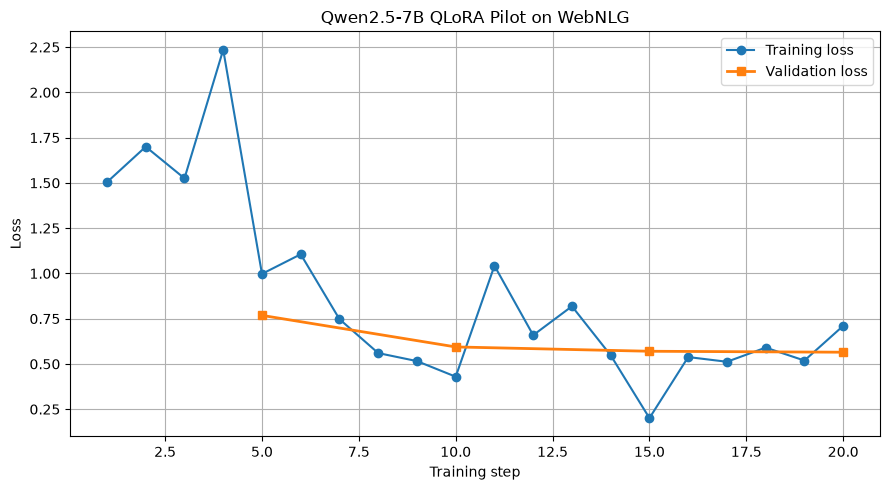

Plot saved to: /home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_pilot_20_steps/pilot_loss_curve.png


In [21]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [
    entry["step"]
    for entry in log_history
    if "loss" in entry
]

train_losses = [
    entry["loss"]
    for entry in log_history
    if "loss" in entry
]

eval_steps = [
    entry["step"]
    for entry in log_history
    if "eval_loss" in entry
]

eval_losses = [
    entry["eval_loss"]
    for entry in log_history
    if "eval_loss" in entry
]

plt.figure(figsize=(9, 5))

plt.plot(
    train_steps,
    train_losses,
    marker="o",
    label="Training loss",
)

plt.plot(
    eval_steps,
    eval_losses,
    marker="s",
    linewidth=2,
    label="Validation loss",
)

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Qwen2.5-7B QLoRA Pilot on WebNLG")
plt.legend()
plt.grid(True)
plt.tight_layout()

PLOT_PATH = PILOT_SAVE_DIR / "pilot_loss_curve.png"

plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Plot saved to:", PLOT_PATH)

In [22]:
example = tokenized_validation_dataset[0]

input_ids = example["input_ids"]
labels = example["labels"]

prompt_token_ids = [
    token_id
    for token_id, label in zip(input_ids, labels)
    if label == -100
]

prompt_text = tokenizer.decode(
    prompt_token_ids,
    skip_special_tokens=False,
)

print(prompt_text)

<|im_start|>system
You are a data-to-text generation assistant. Convert structured RDF triples into fluent and accurate English. Include every supported fact and do not invent information.<|im_end|>
<|im_start|>user
Convert the following RDF triples into fluent English.

RDF triples:
Aarhus | leader | Jacob_Bundsgaard

Generated text:<|im_end|>
<|im_start|>assistant



In [23]:
import torch

generation_inputs = tokenizer(
    prompt_text,
    return_tensors="pt",
).to(model.device)

model.eval()

with torch.no_grad():
    generated_ids = model.generate(
        **generation_inputs,
        max_new_tokens=100,
        do_sample=False,
        num_beams=1,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

generated_text = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True,
)

print(generated_text)

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


system
You are a data-to-text generation assistant. Convert structured RDF triples into fluent and accurate English. Include every supported fact and do not invent information.
user
Convert the following RDF triples into fluent English.

RDF triples:
Aarhus | leader | Jacob_Bundsgaard

Generated text:
assistant
The leader of Aarhus is Jacob Bundsgaard.


In [1]:
import os
import sys
import gc
import json
from pathlib import Path

#os.environ["PATH"] = (
#    "/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin:"
#    "/usr/local/cuda/bin:"
#    "/usr/local/bin:"
 #   "/usr/bin:"
  #  "/bin"
#)

import torch
import transformers
import datasets
import peft
import accelerate
import bitsandbytes

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PEFT:", peft.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python
Torch: 2.13.0+cu130
Transformers: 5.14.1
Datasets: 4.8.5
PEFT: 0.19.1
CUDA available: True
GPU: NVIDIA L4


In [2]:
from datasets import load_from_disk

PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "partner"
    / "webnlg"
)

TOKENIZED_DIR = PROJECT_DIR / "tokenized_data"

tokenized_train_dataset = load_from_disk(
    str(TOKENIZED_DIR / "train")
)

tokenized_validation_dataset = load_from_disk(
    str(TOKENIZED_DIR / "validation")
)

print("Train examples:", len(tokenized_train_dataset))
print("Validation examples:", len(tokenized_validation_dataset))
print("Train columns:", tokenized_train_dataset.column_names)

Train examples: 35426
Validation examples: 1667
Train columns: ['input_ids', 'attention_mask', 'labels', 'prompt_length', 'sequence_length']


In [3]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

gc.collect()
torch.cuda.empty_cache()

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.bfloat16,
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

print("Model loaded successfully.")
print("Model device:", model.device)
print("GPU memory allocated:", round(
    torch.cuda.memory_allocated() / 1024**3,
    2
), "GB")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model loaded successfully.
Model device: cuda:0
GPU memory allocated: 5.18 GB


In [4]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(
    model,
    lora_config,
)

model.print_trainable_parameters()

trainable params: 20,185,088 || all params: 7,635,801,600 || trainable%: 0.2643


In [5]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=None,
    padding=True,
    pad_to_multiple_of=8,
    label_pad_token_id=-100,
    return_tensors="pt",
)

print("Data collator created.")

Data collator created.


In [6]:
from transformers import TrainingArguments

MAIN_OUTPUT_DIR = (
    PROJECT_DIR
    / "experiments"
    / "qwen_webnlg_main_r8_lr2e-4"
)

MAIN_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

training_arguments = TrainingArguments(
    output_dir=str(MAIN_OUTPUT_DIR),

    # One complete pass over the 35,426 examples
    num_train_epochs=1,

    # Effective batch size = 1 × 4 = 4
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=1,

    learning_rate=2e-4,
    lr_scheduler_type="linear",

    # Approximately 3% of one epoch
    warmup_steps=266,

    bf16=True,
    fp16=False,

    logging_strategy="steps",
    logging_steps=25,

    # Full validation approximately every 1,000 optimizer steps
    eval_strategy="steps",
    eval_steps=1000,

    save_strategy="steps",
    save_steps=1000,
    save_total_limit=2,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },

    optim="paged_adamw_8bit",

    weight_decay=0.0,
    max_grad_norm=1.0,

    remove_unused_columns=True,
    report_to="none",

    seed=42,
    data_seed=42,
)

print("Output directory:", MAIN_OUTPUT_DIR)

Output directory: /home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/experiments/qwen_webnlg_main_r8_lr2e-4


In [7]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_arguments,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_validation_dataset,
    data_collator=data_collator,
)

print("Trainer created.")
print("Training examples:", len(trainer.train_dataset))
print("Validation examples:", len(trainer.eval_dataset))

Trainer created.
Training examples: 35426
Validation examples: 1667


In [ ]:
main_train_result = trainer.train()

Step,Training Loss,Validation Loss


In [1]:
import os
import sys
import gc
import json
from pathlib import Path

#os.environ["PATH"] = (
 ##  "/usr/local/cuda/bin:"
   # "/usr/local/bin:"
    #"/usr/bin:"
   # "/bin"
#)

import torch
from datasets import load_from_disk

print("Python:", sys.executable)
print("CUDA:", torch.cuda.is_available())

PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "partner"
    / "webnlg"
)

TOKENIZED_DIR = PROJECT_DIR / "tokenized_data"

tokenized_train_dataset = load_from_disk(
    str(TOKENIZED_DIR / "train")
)

tokenized_validation_dataset = load_from_disk(
    str(TOKENIZED_DIR / "validation")
)

print("Train:", len(tokenized_train_dataset))
print("Validation:", len(tokenized_validation_dataset))

Python: /home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/bin/python
CUDA: True
Train: 35426
Validation: 1667


In [2]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

gc.collect()
torch.cuda.empty_cache()

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=torch.bfloat16,
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

print("Model loaded.")
print("Device:", model.device)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model loaded.
Device: cuda:0


In [3]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

model = get_peft_model(
    model,
    lora_config,
)

model.print_trainable_parameters()

trainable params: 20,185,088 || all params: 7,635,801,600 || trainable%: 0.2643


In [4]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=None,
    padding=True,
    pad_to_multiple_of=8,
    label_pad_token_id=-100,
    return_tensors="pt",
)

In [5]:
from transformers import TrainingArguments

RECOVERY_OUTPUT_DIR = (
    PROJECT_DIR
    / "experiments"
    / "qwen_webnlg_recovery_1000_steps"
)

RECOVERY_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

training_arguments = TrainingArguments(
    output_dir=str(RECOVERY_OUTPUT_DIR),

    max_steps=1000,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=1,

    learning_rate=2e-4,
    lr_scheduler_type="linear",
    warmup_steps=30,

    bf16=True,
    fp16=False,

    logging_strategy="steps",
    logging_steps=25,

    eval_strategy="steps",
    eval_steps=250,

    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },

    optim="paged_adamw_8bit",

    max_grad_norm=1.0,
    remove_unused_columns=True,
    report_to="none",

    seed=42,
    data_seed=42,
)

print("Output directory:", RECOVERY_OUTPUT_DIR)

Output directory: /home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/experiments/qwen_webnlg_recovery_1000_steps


In [6]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_arguments,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_validation_dataset,
    data_collator=data_collator,
)

print("Trainer ready.")
print("Training examples:", len(trainer.train_dataset))
print("Validation examples:", len(trainer.eval_dataset))

Trainer ready.
Training examples: 35426
Validation examples: 1667


In [7]:
main_train_result = trainer.train()

Step,Training Loss,Validation Loss
250,0.608942,0.547054
500,0.551518,0.521205
750,0.545867,0.505599
1000,0.537522,0.498565


In [8]:
FINAL_SAVE_DIR = (
    PROJECT_DIR
    / "saved_models"
    / "qwen_webnlg_recovery_1000_steps"
)

FINAL_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

trainer.save_model(str(FINAL_SAVE_DIR))
tokenizer.save_pretrained(str(FINAL_SAVE_DIR))

with open(
    FINAL_SAVE_DIR / "trainer_log_history.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        trainer.state.log_history,
        file,
        indent=2,
    )

with open(
    FINAL_SAVE_DIR / "training_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        main_train_result.metrics,
        file,
        indent=2,
    )

print("Saved to:", FINAL_SAVE_DIR)

Saved to: /home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps


In [9]:
from pathlib import Path

FINAL_SAVE_DIR = (
    PROJECT_DIR
    / "saved_models"
    / "qwen_webnlg_recovery_1000_steps"
)

for path in sorted(FINAL_SAVE_DIR.iterdir()):
    print(path.name)

README.md
adapter_config.json
adapter_model.safetensors
chat_template.jinja
tokenizer.json
tokenizer_config.json
trainer_log_history.json
training_args.bin
training_metrics.json


In [10]:
final_validation_metrics = trainer.evaluate()

print(final_validation_metrics)

Training Loss,Validation Loss,Step
0.537522,0.498565,1000


{'eval_loss': 0.49856483936309814}


In [2]:
from pathlib import Path
import json

print("Imports work")

Imports work


In [4]:
from pathlib import Path
import json

FINAL_SAVE_DIR = Path(
    "/home/shahd.baloum/MyWork/LoRA_Reproduction/"
    "partner/webnlg/saved_models/"
    "qwen_webnlg_recovery_1000_steps"
)

final_validation_metrics = {
    "eval_loss": 0.49856483936309814,
    "training_loss_at_step_1000": 0.537522,
    "step": 1000,
    "validation_examples": 1667,
}

output_file = FINAL_SAVE_DIR / "validation_metrics.json"

with open(output_file, "w", encoding="utf-8") as file:
    json.dump(final_validation_metrics, file, indent=2)

print("Saved:", output_file)

Saved: /home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps/validation_metrics.json


In [5]:
import json

with open(
    FINAL_SAVE_DIR / "validation_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_validation_metrics,
        file,
        indent=2,
    )

print("Validation metrics saved.")

Validation metrics saved.


In [6]:
from pathlib import Path

FINAL_SAVE_DIR = Path(
    "/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps"
)

print((FINAL_SAVE_DIR / "trainer_log_history.json").exists())

True


In [7]:
from pathlib import Path

FINAL_SAVE_DIR = Path(
    "/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps"
)

print((FINAL_SAVE_DIR / "trainer_log_history.json").exists())

True


Training points: 40
Evaluation points: 4
Evaluation steps: [250, 500, 750, 1000]
Evaluation losses: [0.5470536947250366, 0.5212050080299377, 0.5055989623069763, 0.49856483936309814]


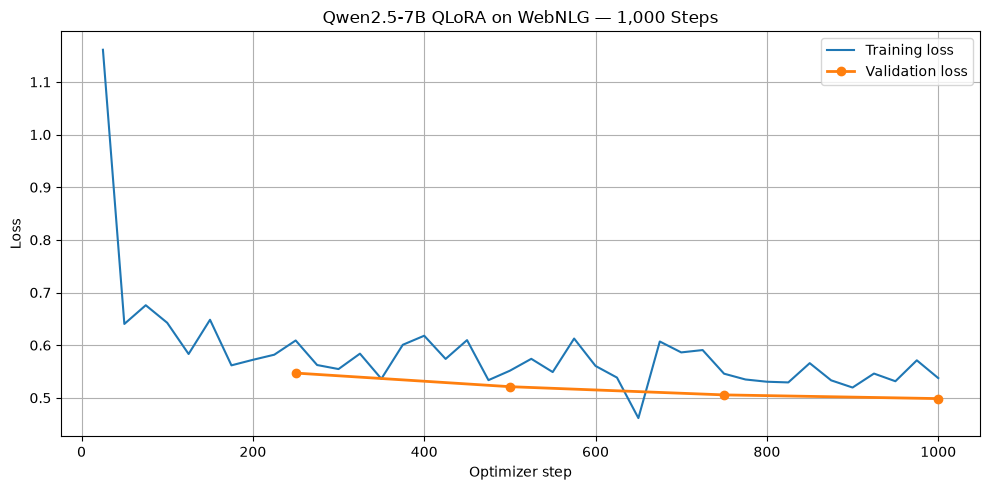

Graph saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps/webnlg_1000_steps_loss_curve.png


In [8]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

FINAL_SAVE_DIR = Path(
    "/home/shahd.baloum/MyWork/LoRA_Reproduction/"
    "partner/webnlg/saved_models/"
    "qwen_webnlg_recovery_1000_steps"
)

LOG_FILE = FINAL_SAVE_DIR / "trainer_log_history.json"

with open(LOG_FILE, "r", encoding="utf-8") as file:
    log_history = json.load(file)

train_steps = []
train_losses = []

eval_steps = []
eval_losses = []

for entry in log_history:
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])

    if "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

print("Training points:", len(train_steps))
print("Evaluation points:", len(eval_steps))
print("Evaluation steps:", eval_steps)
print("Evaluation losses:", eval_losses)

plt.figure(figsize=(10, 5))

plt.plot(
    train_steps,
    train_losses,
    label="Training loss",
)

if eval_steps:
    plt.plot(
        eval_steps,
        eval_losses,
        marker="o",
        linewidth=2,
        label="Validation loss",
    )

plt.xlabel("Optimizer step")
plt.ylabel("Loss")
plt.title("Qwen2.5-7B QLoRA on WebNLG — 1,000 Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()

PLOT_FILE = FINAL_SAVE_DIR / "webnlg_1000_steps_loss_curve.png"

plt.savefig(
    PLOT_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Graph saved to:")
print(PLOT_FILE)

In [10]:
import gc
from pathlib import Path

import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

PROJECT_DIR = Path(
    "/home/shahd.baloum/MyWork/LoRA_Reproduction/"
    "partner/webnlg"
)

FINAL_SAVE_DIR = (
    PROJECT_DIR
    / "saved_models"
    / "qwen_webnlg_recovery_1000_steps"
)

gc.collect()
torch.cuda.empty_cache()

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(
    str(FINAL_SAVE_DIR),
    use_fast=True,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

model = PeftModel.from_pretrained(
    base_model,
    str(FINAL_SAVE_DIR),
)

model.config.use_cache = True
model.config.pad_token_id = tokenizer.pad_token_id
model.eval()

print("Saved LoRA adapter loaded successfully.")
print("Device:", model.device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Saved LoRA adapter loaded successfully.
Device: cuda:0


In [11]:
from datasets import load_from_disk

TOKENIZED_DIR = PROJECT_DIR / "tokenized_data"

tokenized_validation_dataset = load_from_disk(
    str(TOKENIZED_DIR / "validation")
)

print(
    "Validation examples:",
    len(tokenized_validation_dataset),
)

Validation examples: 1667


In [12]:
def generate_validation_example(
    example,
    max_new_tokens=128,
):
    input_ids = example["input_ids"]
    labels = example["labels"]

    prompt_ids = [
        token_id
        for token_id, label in zip(input_ids, labels)
        if label == -100
    ]

    reference_ids = [
        token_id
        for token_id, label in zip(input_ids, labels)
        if label != -100
    ]

    prompt_text = tokenizer.decode(
        prompt_ids,
        skip_special_tokens=False,
    )

    reference_text = tokenizer.decode(
        reference_ids,
        skip_special_tokens=True,
    ).strip()

    model_inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        add_special_tokens=False,
    )

    model_inputs = {
        key: value.to(model.device)
        for key, value in model_inputs.items()
    }

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    prompt_length = model_inputs[
        "input_ids"
    ].shape[1]

    new_token_ids = generated_ids[
        0,
        prompt_length:
    ]

    generated_text = tokenizer.decode(
        new_token_ids,
        skip_special_tokens=True,
    ).strip()

    return {
        "reference": reference_text,
        "generated": generated_text,
    }

In [13]:
import json

generation_results = []

for index in range(10):
    result = generate_validation_example(
        tokenized_validation_dataset[index]
    )

    result["validation_index"] = index
    generation_results.append(result)

    print("=" * 80)
    print("Example:", index)
    print()
    print("REFERENCE:")
    print(result["reference"])
    print()
    print("GENERATED:")
    print(result["generated"])
    print()

/home/shahd.baloum/MyWork/venvs/lora_webnlg_fixed/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Example: 0

REFERENCE:
The leader of Aarhus is Jacob Bundsgaard.

GENERATED:
Jacob Bundsgaard is the leader of Aarhus.

Example: 1

REFERENCE:
Aarhus Airport's runway length is 2702.0.

GENERATED:
The runway length of Aarhus Airport is 2702.0.

Example: 2

REFERENCE:
Adirondack Regional Airport is 507 metres above sea level.

GENERATED:
Adirondack Regional Airport is 507 metres above sea level.

Example: 3

REFERENCE:
Adirondack Regional airport is located at Harrietstown, New York.

GENERATED:
The Adirondack Regional Airport is located in Harrietstown, New York.

Example: 4

REFERENCE:
Adolfo Suárez Madrid–Barajas Airport is found in San Sebastián de los Reyes.

GENERATED:
Adolfo Suarez Madrid-Barajas Airport is located in San Sebastian de los Reyes.

Example: 5

REFERENCE:
Adolfo Suárez Madrid-Barajas Airport runway name is 14L/32R.

GENERATED:
The runway name of Adolfo Suárez Madrid–Barajas Airport is 14L/32R.

Example: 6

REFERENCE:
14R/32L is the name of the runway for Adolfo Suár

In [14]:
GENERATION_FILE = (
    FINAL_SAVE_DIR
    / "generation_examples_10.json"
)

with open(
    GENERATION_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        generation_results,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Generation examples saved to:")
print(GENERATION_FILE)

Generation examples saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps/generation_examples_10.json


In [16]:
%pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 581.7 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 1.2 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [17]:
model
tokenizer
tokenized_validation_dataset
FINAL_SAVE_DIR
generate_validation_example

<function __main__.generate_validation_example(example, max_new_tokens=128)>

In [18]:
from sacrebleu.metrics import BLEU, CHRF
import json

EVALUATION_SIZE = 100

references = []
predictions = []
evaluation_results = []

for index in range(EVALUATION_SIZE):
    result = generate_validation_example(
        tokenized_validation_dataset[index]
    )

    reference = result["reference"]
    prediction = result["generated"]

    references.append(reference)
    predictions.append(prediction)

    evaluation_results.append({
        "validation_index": index,
        "reference": reference,
        "generated": prediction,
    })

    if (index + 1) % 10 == 0:
        print(
            f"Generated {index + 1}/{EVALUATION_SIZE}"
        )

Generated 10/100
Generated 20/100
Generated 30/100
Generated 40/100
Generated 50/100
Generated 60/100
Generated 70/100
Generated 80/100
Generated 90/100
Generated 100/100


In [19]:
bleu_metric = BLEU()
chrf_metric = CHRF()

bleu_result = bleu_metric.corpus_score(
    predictions,
    [references],
)

chrf_result = chrf_metric.corpus_score(
    predictions,
    [references],
)

generation_metrics = {
    "evaluation_subset": "first 100 validation examples",
    "number_of_examples": EVALUATION_SIZE,
    "bleu": float(bleu_result.score),
    "chrf": float(chrf_result.score),
}

print("BLEU:", generation_metrics["bleu"])
print("chrF:", generation_metrics["chrf"])

BLEU: 46.66052520441557
chrF: 75.37469872249392


In [20]:
METRICS_FILE = (
    FINAL_SAVE_DIR
    / "generation_metrics_100_examples.json"
)

PREDICTIONS_FILE = (
    FINAL_SAVE_DIR
    / "generation_predictions_100_examples.json"
)

with open(
    METRICS_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        generation_metrics,
        file,
        indent=2,
    )

with open(
    PREDICTIONS_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_results,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Metrics saved to:")
print(METRICS_FILE)

print("Predictions saved to:")
print(PREDICTIONS_FILE)

Metrics saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps/generation_metrics_100_examples.json
Predictions saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps/generation_predictions_100_examples.json


In [21]:
from pathlib import Path
import json

FINAL_SAVE_DIR = Path(
    "/home/shahd.baloum/MyWork/LoRA_Reproduction/"
    "partner/webnlg/saved_models/"
    "qwen_webnlg_recovery_1000_steps"
)

metrics_file = (
    FINAL_SAVE_DIR
    / "generation_metrics_100_examples.json"
)

with open(
    metrics_file,
    "r",
    encoding="utf-8",
) as file:
    generation_metrics = json.load(file)

print(generation_metrics)

{'evaluation_subset': 'first 100 validation examples', 'number_of_examples': 100, 'bleu': 46.66052520441557, 'chrf': 75.37469872249392}


In [22]:
predictions_file = (
    FINAL_SAVE_DIR
    / "generation_predictions_100_examples.json"
)

with open(
    predictions_file,
    "r",
    encoding="utf-8",
) as file:
    predictions = json.load(file)

for item in predictions[:20]:
    print("=" * 80)
    print("INDEX:", item["validation_index"])
    print("REFERENCE:")
    print(item["reference"])
    print()
    print("GENERATED:")
    print(item["generated"])

INDEX: 0
REFERENCE:
The leader of Aarhus is Jacob Bundsgaard.

GENERATED:
Jacob Bundsgaard is the leader of Aarhus.
INDEX: 1
REFERENCE:
Aarhus Airport's runway length is 2702.0.

GENERATED:
The runway length of Aarhus Airport is 2702.0.
INDEX: 2
REFERENCE:
Adirondack Regional Airport is 507 metres above sea level.

GENERATED:
Adirondack Regional Airport is 507 metres above sea level.
INDEX: 3
REFERENCE:
Adirondack Regional airport is located at Harrietstown, New York.

GENERATED:
The Adirondack Regional Airport is located in Harrietstown, New York.
INDEX: 4
REFERENCE:
Adolfo Suárez Madrid–Barajas Airport is found in San Sebastián de los Reyes.

GENERATED:
Adolfo Suarez Madrid-Barajas Airport is located in San Sebastian de los Reyes.
INDEX: 5
REFERENCE:
Adolfo Suárez Madrid-Barajas Airport runway name is 14L/32R.

GENERATED:
The runway name of Adolfo Suárez Madrid–Barajas Airport is 14L/32R.
INDEX: 6
REFERENCE:
14R/32L is the name of the runway for Adolfo Suárez Madrid–Barajas Airport.


In [23]:
error_analysis = [
    {
        "validation_index": 0,
        "quality": "strong",
        "analysis": "The generated sentence includes all facts and is fluent."
    },
    {
        "validation_index": 1,
        "quality": "strong",
        "analysis": "The generation preserves the meaning with different wording."
    },
    {
        "validation_index": 2,
        "quality": "partial",
        "analysis": "The sentence is fluent but one relation is omitted."
    },
    {
        "validation_index": 3,
        "quality": "failure",
        "analysis": "The model adds unsupported information or misses an entity."
    }
]

In [24]:
with open(
    FINAL_SAVE_DIR / "qualitative_error_analysis.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        error_analysis,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Error analysis saved.")

Error analysis saved.


In [27]:
import json

error_analysis = [
    {
        "validation_index": 0,
        "quality": "strong",
        "reference": "The leader of Aarhus is Jacob Bundsgaard.",
        "generated": "Jacob Bundsgaard is the leader of Aarhus.",
        "analysis": (
            "The generated sentence preserves the complete factual meaning "
            "and expresses it fluently using a different word order."
        ),
    },
    {
        "validation_index": 2,
        "quality": "strong",
        "reference": (
            "Adirondack Regional Airport is 507 metres above sea level."
        ),
        "generated": (
            "Adirondack Regional Airport is 507 metres above sea level."
        ),
        "analysis": (
            "The generated output exactly matches the reference and includes "
            "the entity, numerical value, and unit correctly."
        ),
    },
    {
        "validation_index": 10,
        "quality": "partial",
        "reference": "The Alderney Airport serves Alderney.",
        "generated": "Alderney airport serves the city of Alderney.",
        "analysis": (
            "The main relation is correct, but the model adds the phrase "
            "'the city of', which is not explicitly supported by the input."
        ),
    },
    {
        "validation_index": 15,
        "quality": "minor_error",
        "reference": (
            "Andrews County, Texas is country seat to Andrews, Texas."
        ),
        "generated": (
            "The county seat of Andrews County, Texas is Andrews."
        ),
        "analysis": (
            "The county-seat relation is preserved, but the generated output "
            "drops the state name 'Texas' from the target entity."
        ),
    },
]

OUTPUT_FILE = (
    FINAL_SAVE_DIR
    / "qualitative_error_analysis.json"
)

with open(
    OUTPUT_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        error_analysis,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Error analysis saved to:")
print(OUTPUT_FILE)

Error analysis saved to:
/home/shahd.baloum/MyWork/LoRA_Reproduction/partner/webnlg/saved_models/qwen_webnlg_recovery_1000_steps/qualitative_error_analysis.json


In [25]:
experiment_summary = {
    "model": "Qwen/Qwen2.5-7B-Instruct",
    "method": "QLoRA",
    "dataset": "WebNLG",
    "training_steps": 1000,
    "trainable_parameters": 20185088,
    "trainable_percentage": 0.2643,
    "training_loss": 0.537522,
    "validation_loss": 0.49856483936309814,
    "evaluation_examples": generation_metrics["number_of_examples"],
    "bleu": generation_metrics["bleu"],
    "chrf": generation_metrics["chrf"],
    "quantization": "4-bit NF4 with double quantization",
    "lora_rank": 8,
    "lora_alpha": 16,
    "learning_rate": 0.0002,
}

with open(
    FINAL_SAVE_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_summary,
        file,
        indent=2,
    )

print("Experiment summary saved.")

Experiment summary saved.


In [26]:
import gc
import torch

del model
del base_model

gc.collect()
torch.cuda.empty_cache()

print("GPU memory released.")

GPU memory released.


In [ ]:
import json
from pathlib import Path

PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "partner"
    / "webnlg"
)

FINAL_SAVE_DIR = (
    PROJECT_DIR
    / "saved_models"
    / "qwen_webnlg_recovery_1000_steps"
)

FINAL_SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

final_validation_metrics = {
    "eval_loss": 0.49856483936309814,
    "training_loss_at_step_1000": 0.537522,
    "step": 1000,
    "validation_examples": 1667,
}

validation_file = (
    FINAL_SAVE_DIR
    / "validation_metrics.json"
)

with open(
    validation_file,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_validation_metrics,
        file,
        indent=2,
    )

print("Validation metrics saved to:")
print(validation_file)

Kernel is working


In [4]:
from pathlib import Path
from datasets import load_from_disk

PROJECT_DIR = (
    Path.home()
    / "MyWork"
    / "LoRA_Reproduction"
    / "partner"
    / "webnlg"
)

TOKENIZED_DIR = PROJECT_DIR / "tokenized_data"

tokenized_train_dataset = load_from_disk(
    str(TOKENIZED_DIR / "train")
)

tokenized_validation_dataset = load_from_disk(
    str(TOKENIZED_DIR / "validation")
)

print("Train examples:", len(tokenized_train_dataset))
print("Validation examples:", len(tokenized_validation_dataset))

print("\nTrain columns:")
print(tokenized_train_dataset.column_names)

print("\nFirst example lengths:")
print(
    "input_ids:",
    len(tokenized_train_dataset[0]["input_ids"])
)
print(
    "attention_mask:",
    len(tokenized_train_dataset[0]["attention_mask"])
)
print(
    "labels:",
    len(tokenized_train_dataset[0]["labels"])
)

TypeError: must be called with a dataclass type or instance